# QM7 Quantum-Classical Hybrid Molecular Energy Prediction
## A Comprehensive Benchmark

**Dataset:** QM7 – 7,165 small organic molecules, Coulomb matrix representation  
**Task:** Regression – predict atomization energy (kcal/mol)  
**Models:** Ridge · SVR · RF · MLP · VQR · QCNN-R · QKernel-SVR · QAOA-VQR · HybridNet · QuantumBoost · QResNet  
**Experiments:** Feature engineering · Input-size sweep · Ablation · Extended ablation · 5-fold CV · Noise analysis · Hardware · Statistical tests · Best-model summary  
**New Feature:** Model weight/parameter counter  

### What is QM7?
QM7 contains 7,165 small organic molecules (up to 23 atoms: C, H, N, O, S).  
Each molecule is encoded as a **Coulomb matrix** — a 23×23 physics-motivated matrix.  
The target is the **atomization energy** in kcal/mol (range −2192 to −405).

| Field | Shape | Description |
|-------|-------|-------------|
| `X` Coulomb matrices | (7165,23,23) | Diagonal: 0.5·Zᵢ²·⁴. Off-diag: ZᵢZⱼ/rᵢⱼ. Zero-padded. |
| `R` Atom positions | (7165,23,3) | 3D Cartesian coordinates (Å), zero-padded |
| `Z` Atomic numbers | (7165,23) | 0=empty, 1=H, 6=C, 7=N, 8=O, 16=S |
| `T` Target energies | (7165,) | Atomization energy in kcal/mol |
| `P` CV splits | (5,1433) | 5 predefined cross-validation fold indices |

## 0) Installation

In [1]:
# !pip install qiskit qiskit-aer qiskit-machine-learning scikit-learn scipy matplotlib seaborn

## 1) Imports and Config

In [2]:
import time, warnings, itertools, os, json, copy
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from collections import Counter
from dataclasses import dataclass
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import ttest_rel, friedmanchisquare

GLOBAL_SEED = 42
QM7_PATH    = 'datasets/qm7.mat'
OUT_DIR     = 'outputs/qm7/'
RES_DIR     = 'results/qm7/'
SANITY_MAE_LIMIT = 500.0
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)
ATOM_SYMBOLS = {0:'_', 1:'H', 6:'C', 7:'N', 8:'O', 16:'S'}

def set_seed(seed=GLOBAL_SEED):
    np.random.seed(seed)

set_seed()
print("Imports done.")

Imports done.


## 2) Data Loading

In [3]:
qm7   = scipy.io.loadmat(QM7_PATH)
X_raw = qm7['X']
R_raw = qm7['R']
Z_raw = qm7['Z']
T_raw = qm7['T'].flatten()
P_raw = qm7['P']
print(f"Molecules: {X_raw.shape[0]:,}")
print(f"Target range: {T_raw.min():.1f} to {T_raw.max():.1f} kcal/mol")
print(f"Target mean+-std: {T_raw.mean():.1f} +- {T_raw.std():.1f}")

def atom_counts(z_row):
    c = {}
    for z in z_row:
        if int(z)==0: continue
        s = ATOM_SYMBOLS.get(int(z), f'Z{int(z)}')
        c[s] = c.get(s,0)+1
    return c

def molecular_formula(z_row):
    c = atom_counts(z_row)
    return ''.join(s+(str(c[s]) if c[s]>1 else '') for s in ['C','H','N','O','S'] if s in c)

print("\nFirst 5 molecules:")
for i in range(5):
    z=Z_raw[i]; e=T_raw[i]; n=int((z!=0).sum()); fmt=molecular_formula(z)
    print(f"  #{i} {fmt:10s} atoms={n}  energy={e:.2f} kcal/mol")

Molecules: 7,165
Target range: -2192.0 to -404.9 kcal/mol
Target mean+-std: -1538.0 +- 223.9

First 5 molecules:
  #0 CH4        atoms=5  energy=-417.96 kcal/mol
  #1 C2H6       atoms=8  energy=-712.42 kcal/mol
  #2 C2H4       atoms=6  energy=-564.21 kcal/mol
  #3 C2H2       atoms=4  energy=-404.88 kcal/mol
  #4 C2H6O      atoms=9  energy=-808.87 kcal/mol


## 3) EDA

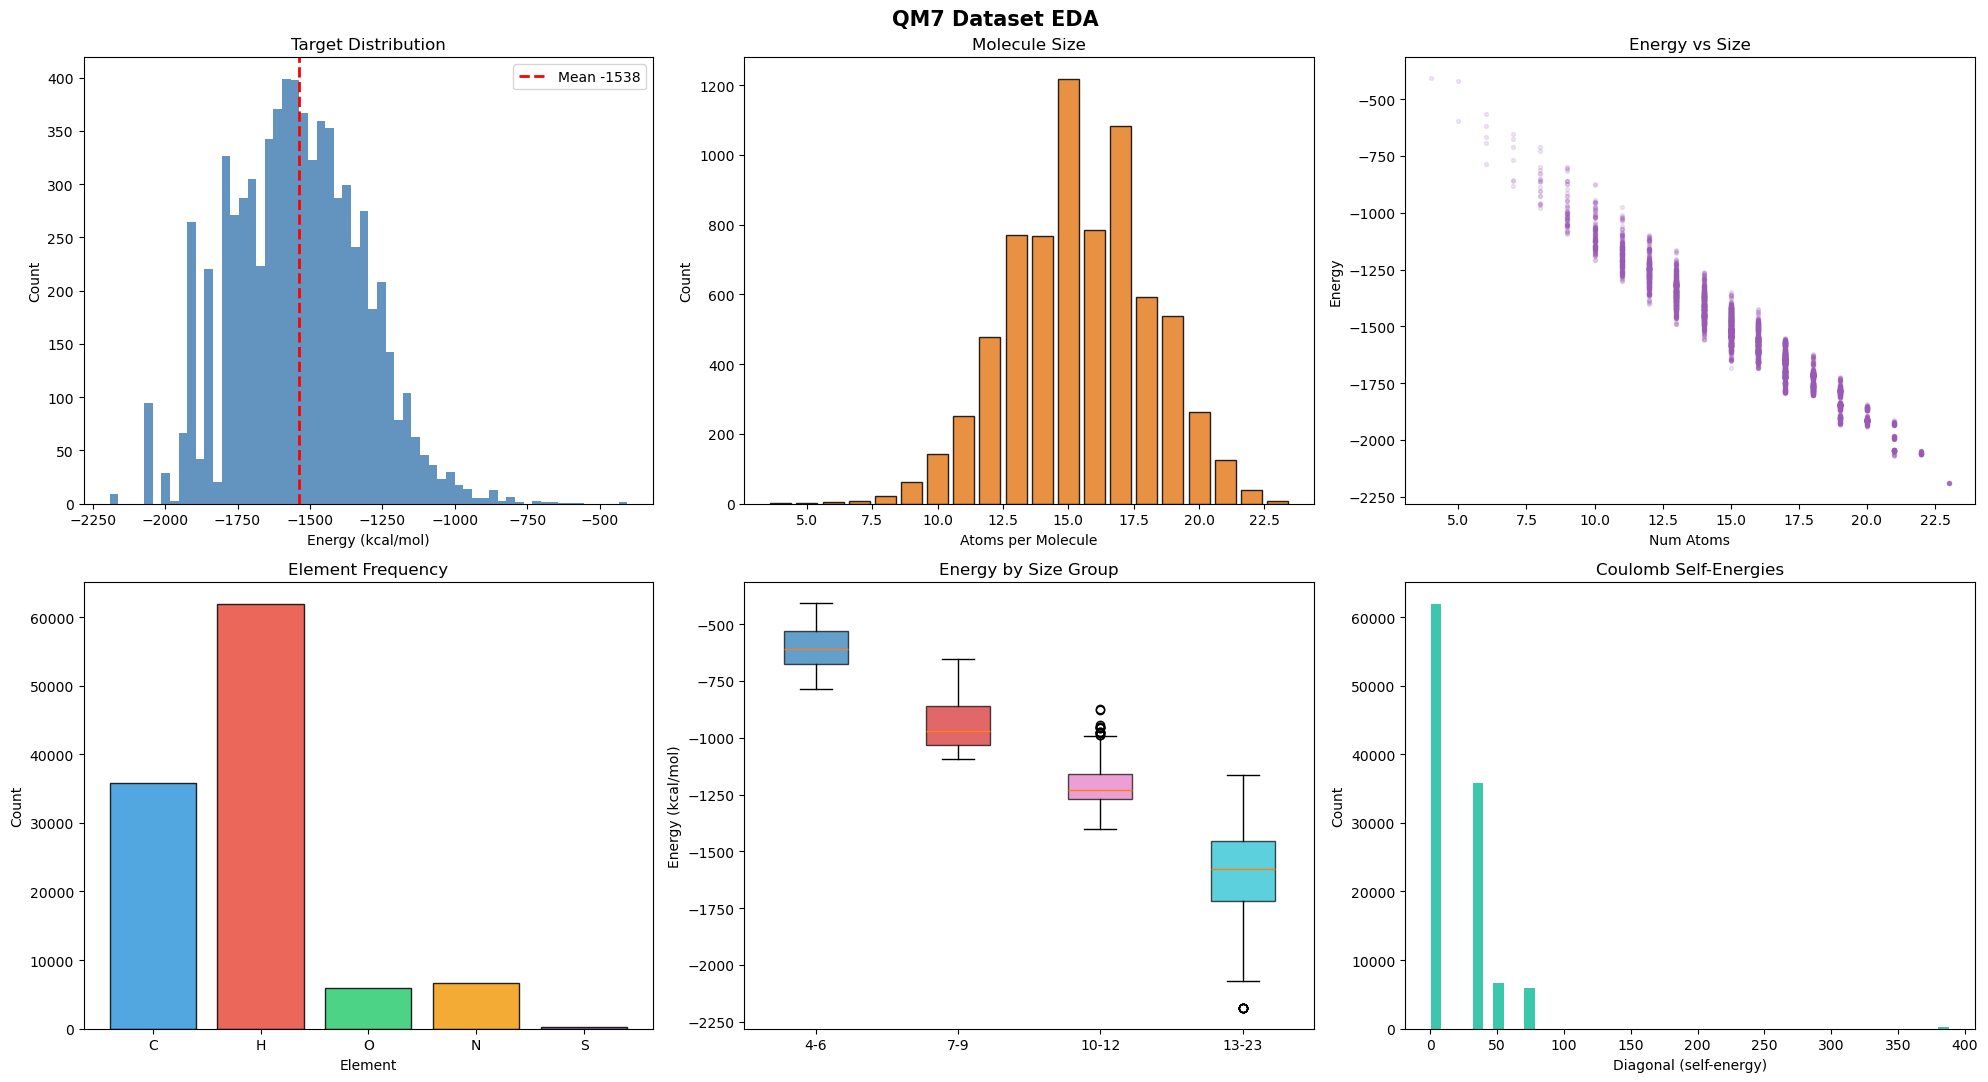

EDA saved.


In [4]:
n_atoms = (Z_raw!=0).sum(axis=1)
fig,axes=plt.subplots(2,3,figsize=(20,11))
fig.suptitle('QM7 Dataset EDA',fontsize=15,fontweight='bold')
axes[0,0].hist(T_raw,bins=60,color='steelblue',edgecolor='none',alpha=0.85)
axes[0,0].axvline(T_raw.mean(),color='red',ls='--',lw=2,label=f'Mean {T_raw.mean():.0f}')
axes[0,0].set(xlabel='Energy (kcal/mol)',ylabel='Count',title='Target Distribution'); axes[0,0].legend()
vals,cnts=np.unique(n_atoms,return_counts=True)
axes[0,1].bar(vals,cnts,color='#e67e22',edgecolor='k',alpha=0.85)
axes[0,1].set(xlabel='Atoms per Molecule',ylabel='Count',title='Molecule Size')
axes[0,2].scatter(n_atoms,T_raw,alpha=0.15,s=8,color='#9b59b6')
axes[0,2].set(xlabel='Num Atoms',ylabel='Energy',title='Energy vs Size')
elem_all=Counter()
for i in range(len(Z_raw)): elem_all.update(atom_counts(Z_raw[i]))
elems=list(elem_all.keys()); evals=[elem_all[e] for e in elems]
axes[1,0].bar(elems,evals,color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'][:len(elems)],edgecolor='k',alpha=0.85)
axes[1,0].set(xlabel='Element',ylabel='Count',title='Element Frequency')
bins=[1,4,7,10,13,24]; box_data=[]; box_lbl=[]
for j in range(len(bins)-1):
    mask=(n_atoms>=bins[j])&(n_atoms<bins[j+1])
    if mask.sum()>0: box_data.append(T_raw[mask]); box_lbl.append(f'{bins[j]}-{bins[j+1]-1}')
bp=axes[1,1].boxplot(box_data,labels=box_lbl,patch_artist=True)
for patch,col in zip(bp['boxes'],plt.cm.tab10(np.linspace(0,1,len(box_data)))): patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1,1].set(ylabel='Energy (kcal/mol)',title='Energy by Size Group')
diag_flat=np.array([X_raw[i].diagonal() for i in range(len(X_raw))]).flatten(); diag_flat=diag_flat[diag_flat>0]
axes[1,2].hist(diag_flat,bins=50,color='#1abc9c',edgecolor='none',alpha=0.85)
axes[1,2].set(xlabel='Diagonal (self-energy)',ylabel='Count',title='Coulomb Self-Energies')
plt.tight_layout(); plt.savefig(RES_DIR+'eda_overview.png',dpi=120,bbox_inches='tight'); plt.show()
print("EDA saved.")

## 4) Feature Engineering

In [5]:
def extract_cm_eigenvalues(X3d):
    return np.array([np.sort(np.linalg.eigvalsh(X3d[i]))[::-1] for i in range(len(X3d))])

def extract_cm_flat_sorted(X3d):
    N,M,_=X3d.shape; out=[]
    for i in range(N):
        mat=X3d[i].copy(); norms=np.linalg.norm(mat,axis=1); idx=np.argsort(norms)[::-1]
        mat=mat[np.ix_(idx,idx)]; out.append(mat[np.triu_indices(M)])
    return np.array(out)

def extract_cm_summary(X3d,Z3d):
    N=len(X3d); out=np.zeros((N,8))
    for i in range(N):
        mat=X3d[i]; diag=np.diag(mat)
        off=mat[np.triu_indices(mat.shape[0],k=1)]; off=off[off!=0]
        out[i]=[diag.mean(),diag.std(),
                off.mean() if len(off) else 0,off.std() if len(off) else 0,
                np.linalg.norm(mat,'fro'),mat.max(),mat.sum(),(Z3d[i]!=0).sum()]
    return out

print("Extracting features...")
X_eig  = extract_cm_eigenvalues(X_raw)
X_flat = extract_cm_flat_sorted(X_raw)
X_summ = extract_cm_summary(X_raw,Z_raw)
y      = T_raw.copy()
print(f"  Eigenvalues  : {X_eig.shape}")
print(f"  Flat sorted  : {X_flat.shape}")
print(f"  Summary stats: {X_summ.shape}")
print(f"  y range      : [{y.min():.1f}, {y.max():.1f}]")

Extracting features...
  Eigenvalues  : (7165, 23)
  Flat sorted  : (7165, 276)
  Summary stats: (7165, 8)
  y range      : [-2192.0, -404.9]


## 5) Feature Selection

In [6]:
def select_relevant_features(X, y, min_features=4):
    scaler=StandardScaler(); Xs=scaler.fit_transform(X)
    f_scores,_=f_regression(Xs,y); anova_mask=f_scores>=np.median(f_scores)
    rf=RandomForestRegressor(100,random_state=GLOBAL_SEED).fit(Xs,y)
    rf_mask=rf.feature_importances_>=rf.feature_importances_.mean()
    mi=mutual_info_regression(Xs,y,random_state=GLOBAL_SEED); mi_mask=mi>=np.median(mi)
    vote=anova_mask.astype(int)+rf_mask.astype(int)+mi_mask.astype(int); sel=vote>=2
    if sel.sum()<min_features:
        sel=np.zeros(len(f_scores),bool); sel[np.argsort(f_scores)[::-1][:min_features]]=True
    print(f"Selected {sel.sum()}/{len(f_scores)} features")
    return np.where(sel)[0]

rel_idx=select_relevant_features(X_eig,y)
X_rel=X_eig[:,rel_idx]
print(f"Relevant feature matrix: {X_rel.shape}")

Selected 12/23 features
Relevant feature matrix: (7165, 12)


## 6) Y-Normalization and Preprocessing

**THE CRITICAL FIX:** QM7 targets span ~1800 kcal/mol. Without normalization, VQC gradient descent
drives weights to 1e19+ causing MAE ~ 1e19. Fix: z-score normalize targets before quantum training,
inverse-transform predictions before computing metrics.

In [7]:
Y_MEAN = float(y.mean())
Y_STD  = float(y.std())
print(f"y mean={Y_MEAN:.2f}  std={Y_STD:.2f}")

def scale_y(y_arr):
    return (y_arr - Y_MEAN) / Y_STD

def unscale_y(y_scaled):
    return y_scaled * Y_STD + Y_MEAN

y_s = scale_y(y)
print(f"Scaled y: mean={y_s.mean():.4f} std={y_s.std():.4f} range=[{y_s.min():.3f},{y_s.max():.3f}]")
print(f"Roundtrip error: {np.abs(unscale_y(y_s)-y).max():.2e}")

def apply_resampling(X, y, strategy='bootstrap', seed=GLOBAL_SEED):
    if strategy=='none': return X,y
    rng=np.random.default_rng(seed); n=len(X)
    if strategy=='bootstrap':
        idx=rng.integers(0,n,size=n//4); Xr=np.vstack([X,X[idx]]); yr=np.concatenate([y,y[idx]])
    elif strategy=='jitter':
        idx=rng.integers(0,n,size=n//4)
        Xr=np.vstack([X,X[idx]+rng.normal(0,0.01,(len(idx),X.shape[1]))])
        yr=np.concatenate([y,y[idx]+rng.normal(0,y.std()*0.01,len(idx))])
    else: return X,y
    perm=rng.permutation(len(yr)); return Xr[perm],yr[perm]

def preprocess_dataset(X, y, n_features, seed=GLOBAL_SEED, test_size=0.2,
                        resample='none', use_pca=True):
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=test_size,random_state=seed)
    if resample!='none': Xtr,ytr=apply_resampling(Xtr,ytr,strategy=resample,seed=seed)
    sc=StandardScaler(); Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)
    if use_pca and n_features<Xtr.shape[1]:
        pca=PCA(n_components=n_features,random_state=seed)
        Xtr=pca.fit_transform(Xtr); Xte=pca.transform(Xte)
    return Xtr,Xte,ytr,yte

print("Preprocessing utilities ready.")

y mean=-1538.04  std=223.92
Scaled y: mean=0.0000 std=1.0000 range=[-2.921,5.061]
Roundtrip error: 6.10e-05
Preprocessing utilities ready.


## 7) Quantum Models (FIXED)

All quantum/hybrid models now:
1. Call `scale_y(y)` inside `.fit()` before training
2. Call `unscale_y()` inside `.predict()` before returning
3. Use gradient clipping (max norm=1.0)
4. Use Adam-style momentum optimizer
5. Use small weight initialization (sigma=0.01)

In [8]:
def sigmoid(z): return 1./(1.+np.exp(-np.clip(z,-500,500)))

def clip_grad(g, max_norm=1.0):
    n=np.linalg.norm(g)
    return g if n<=max_norm else g*max_norm/(n+1e-12)

class ZZFeatureEncoder:
    def __init__(self,n_qubits): self.n_qubits=n_qubits
    def encode(self,x):
        x=x[:self.n_qubits]; f=list(x)
        for i in range(self.n_qubits-1): f.append((np.pi-x[i])*(np.pi-x[i+1]))
        return np.array(f)
    def encode_batch(self,X): return np.array([self.encode(xi) for xi in X])
    @property
    def dim(self): return self.n_qubits+(self.n_qubits-1)

class PauliEncoder:
    def __init__(self,n_qubits): self.n_qubits=n_qubits
    def encode(self,x):
        x=x[:self.n_qubits]; f=list(x)
        for i in range(self.n_qubits-1): f.append(x[i]*x[i+1])
        for i in range(self.n_qubits-2): f.append(x[i]*x[i+1]*x[i+2])
        return np.array(f)
    def encode_batch(self,X): return np.array([self.encode(xi) for xi in X])
    @property
    def dim(self): return self.n_qubits+(self.n_qubits-1)+max(0,self.n_qubits-2)


class NumpyVQC(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,reps=2,shots=512,seed=GLOBAL_SEED,maxiter=100,encoder='zz'):
        self.n_qubits=n_qubits;self.reps=reps;self.shots=shots;self.seed=seed;self.maxiter=maxiter;self.encoder=encoder
    def _get_enc(self): return ZZFeatureEncoder(self.n_qubits) if self.encoder=='zz' else PauliEncoder(self.n_qubits)
    def fit(self,X,y):
        set_seed(self.seed)
        y_sc=scale_y(y)  # FIX
        enc=self._get_enc(); Xe=enc.encode_batch(X); d=enc.dim
        params=np.random.normal(0,0.01,d+1); self.loss_curve_=[]
        lr=0.02; m=np.zeros_like(params); beta=0.9
        for it in range(self.maxiter):
            noise=np.random.randn(*Xe.shape)/np.sqrt(self.shots)*0.05
            pred=(Xe+noise)@params[:-1]+params[-1]
            loss=np.mean((y_sc-pred)**2)
            if not np.isfinite(loss): break
            self.loss_curve_.append(float(loss))
            grad=np.zeros_like(params)
            for i in range(len(params)):
                pp=params.copy();pp[i]+=np.pi/2;pm=params.copy();pm[i]-=np.pi/2
                grad[i]=(np.mean((y_sc-Xe@pp[:-1]-pp[-1])**2)-np.mean((y_sc-Xe@pm[:-1]-pm[-1])**2))/2
            grad=clip_grad(grad)  # FIX
            m=beta*m+(1-beta)*grad; params-=lr*m/(1-beta**(it+1)); lr*=0.999  # FIX Adam
        self.params_=params; self.enc_=enc; return self
    def predict(self,X):
        return unscale_y(self.enc_.encode_batch(X)@self.params_[:-1]+self.params_[-1])  # FIX


class NumpyQCNN(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,reps=2,shots=512,seed=GLOBAL_SEED,maxiter=100,encoder='zz'):
        self.n_qubits=n_qubits;self.reps=reps;self.shots=shots;self.seed=seed;self.maxiter=maxiter;self.encoder=encoder
    def _cp(self,Xe):
        conv=np.array([Xe[:,i]*Xe[:,i+1] for i in range(Xe.shape[1]-1)]).T
        if conv.shape[1]>=2:
            pool=np.array([conv[:,2*i:2*i+2].mean(1) for i in range(conv.shape[1]//2)]).T
            return np.hstack([Xe,conv,pool])
        return np.hstack([Xe,conv])
    def fit(self,X,y):
        set_seed(self.seed); y_sc=scale_y(y)  # FIX
        enc=ZZFeatureEncoder(self.n_qubits); Xe=self._cp(enc.encode_batch(X)); d=Xe.shape[1]
        params=np.random.normal(0,0.01,d+1); self.loss_curve_=[]
        lr=0.02; m=np.zeros_like(params); beta=0.9
        for it in range(self.maxiter):
            pred=Xe@params[:-1]+params[-1]; loss=np.mean((y_sc-pred)**2)
            if not np.isfinite(loss): break
            self.loss_curve_.append(float(loss))
            grad=np.zeros_like(params); eps=1e-4
            for i in range(len(params)):
                pp=params.copy();pp[i]+=eps;pm=params.copy();pm[i]-=eps
                grad[i]=(np.mean((y_sc-Xe@pp[:-1]-pp[-1])**2)-np.mean((y_sc-Xe@pm[:-1]-pm[-1])**2))/(2*eps)
            grad=clip_grad(grad); m=beta*m+(1-beta)*grad; params-=lr*m/(1-beta**(it+1)); lr*=0.999
        self.params_=params; self.enc_=enc; return self
    def predict(self,X): return unscale_y(self._cp(self.enc_.encode_batch(X))@self.params_[:-1]+self.params_[-1])  # FIX


class NumpyQKernelSVM(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,C=10.0,seed=GLOBAL_SEED):
        self.n_qubits=n_qubits;self.C=C;self.seed=seed
    def _kernel(self,X1,X2):
        enc=ZZFeatureEncoder(self.n_qubits)
        Z1=enc.encode_batch(X1);Z2=enc.encode_batch(X2)
        n1=np.linalg.norm(Z1,axis=1,keepdims=True)+1e-10
        n2=np.linalg.norm(Z2,axis=1,keepdims=True)+1e-10
        return ((Z1/n1)@(Z2/n2).T)**2
    def fit(self,X,y):
        y_sc=scale_y(y)  # FIX
        self.X_train_=X; K=self._kernel(X,X)
        self.svr_=SVR(kernel='precomputed',C=self.C); self.svr_.fit(K,y_sc); self.loss_curve_=[]; return self
    def predict(self,X): return unscale_y(self.svr_.predict(self._kernel(X,self.X_train_)))  # FIX


class NumpyQAOA(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,shots=512,seed=GLOBAL_SEED,maxiter=100,encoder='zz'):
        self.n_qubits=n_qubits;self.shots=shots;self.seed=seed;self.maxiter=maxiter;self.encoder=encoder
    def _enc_qaoa(self,Xe): cost=np.tanh(Xe); return np.hstack([cost,np.roll(cost,1,axis=1)*cost])
    def fit(self,X,y):
        set_seed(self.seed); y_sc=scale_y(y)  # FIX
        enc=ZZFeatureEncoder(self.n_qubits) if self.encoder=='zz' else PauliEncoder(self.n_qubits)
        Xe=self._enc_qaoa(enc.encode_batch(X)); d=Xe.shape[1]
        params=np.random.normal(0,0.01,d+1); self.loss_curve_=[]
        lr=0.02; m=np.zeros_like(params); beta=0.9
        for it in range(self.maxiter):
            pred=Xe@params[:-1]+params[-1]; loss=np.mean((y_sc-pred)**2)
            if not np.isfinite(loss): break
            self.loss_curve_.append(float(loss))
            grad=np.zeros_like(params)
            for i in range(len(params)):
                pp=params.copy();pp[i]+=np.pi/2;pm=params.copy();pm[i]-=np.pi/2
                grad[i]=(np.mean((y_sc-Xe@pp[:-1]-pp[-1])**2)-np.mean((y_sc-Xe@pm[:-1]-pm[-1])**2))/2
            grad=clip_grad(grad); m=beta*m+(1-beta)*grad; params-=lr*m/(1-beta**(it+1))
        self.params_=params; self.enc_=enc; return self
    def predict(self,X): return unscale_y(self._enc_qaoa(self.enc_.encode_batch(X))@self.params_[:-1]+self.params_[-1])  # FIX


class HybridNet(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,hidden=(64,32),seed=GLOBAL_SEED,maxiter=300):
        self.n_qubits=n_qubits;self.hidden=hidden;self.seed=seed;self.maxiter=maxiter
    def fit(self,X,y):
        y_sc=scale_y(y)  # FIX
        enc=ZZFeatureEncoder(self.n_qubits); Xe=enc.encode_batch(X)
        X_aug=np.hstack([X[:,:self.n_qubits],Xe]); self.enc_=enc
        self.mlp_=MLPRegressor(self.hidden,max_iter=self.maxiter,random_state=self.seed,early_stopping=True)
        self.mlp_.fit(X_aug,y_sc); self.loss_curve_=list(getattr(self.mlp_,'loss_curve_',[])); return self
    def predict(self,X):
        Xe=self.enc_.encode_batch(X)
        return unscale_y(self.mlp_.predict(np.hstack([X[:,:self.n_qubits],Xe])))  # FIX


class QuantumBoost(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,n_estimators=100,seed=GLOBAL_SEED):
        self.n_qubits=n_qubits;self.n_estimators=n_estimators;self.seed=seed
    def _qfeat(self,X):
        zz=ZZFeatureEncoder(self.n_qubits).encode_batch(X)
        pau=PauliEncoder(self.n_qubits).encode_batch(X)
        raw=X[:,:self.n_qubits]; return np.hstack([raw,zz,pau,zz[:,:self.n_qubits]-raw])
    def fit(self,X,y):
        y_sc=scale_y(y)  # FIX
        self.gbr_=GradientBoostingRegressor(self.n_estimators,random_state=self.seed)
        self.gbr_.fit(self._qfeat(X),y_sc); self.loss_curve_=list(self.gbr_.train_score_); return self
    def predict(self,X): return unscale_y(self.gbr_.predict(self._qfeat(X)))  # FIX


class QResNet(BaseEstimator, RegressorMixin):
    def __init__(self,n_qubits=4,seed=GLOBAL_SEED):
        self.n_qubits=n_qubits;self.seed=seed
    def _fwd(self,X):
        raw=X[:,:self.n_qubits]; enc=ZZFeatureEncoder(self.n_qubits)
        z1_q=enc.encode_batch(raw); z1=np.hstack([z1_q,raw])
        z1n=StandardScaler().fit_transform(z1[:,:self.n_qubits])
        z2_q=enc.encode_batch(z1n)
        return np.hstack([raw,z1,np.hstack([z2_q,z1[:,:self.n_qubits]])])
    def fit(self,X,y):
        y_sc=scale_y(y)  # FIX
        self.ridge_=Ridge(alpha=1.0); self.ridge_.fit(self._fwd(X),y_sc); self.loss_curve_=[]; return self
    def predict(self,X): return unscale_y(self.ridge_.predict(self._fwd(X)))  # FIX


print("All quantum/hybrid models ready (y-norm + grad-clip + Adam).")

# Quick sanity check
print("\nQuick sanity check:")
set_seed(0)
Xtr_s,Xte_s,ytr_s,yte_s=preprocess_dataset(X_eig,y,4,seed=0,use_pca=True)
for nm,cls_ in [('NumpyVQC',NumpyVQC),('NumpyQCNN',NumpyQCNN),('NumpyQAOA',NumpyQAOA)]:
    m=cls_(n_qubits=4,maxiter=30,seed=0); m.fit(Xtr_s,ytr_s); p=m.predict(Xte_s)
    mae=mean_absolute_error(yte_s,p); ok="OK" if mae<SANITY_MAE_LIMIT else "STILL DIVERGED"
    print(f"  {nm:18s} MAE={mae:8.2f}  R2={r2_score(yte_s,p):.4f}  [{ok}]")

All quantum/hybrid models ready (y-norm + grad-clip + Adam).

Quick sanity check:
  NumpyVQC           MAE=   31.01  R2=0.9704  [OK]
  NumpyQCNN          MAE=  240.91  R2=-12.0279  [OK]
  NumpyQAOA          MAE=   66.20  R2=0.7731  [OK]


## 8) Architecture Diagrams

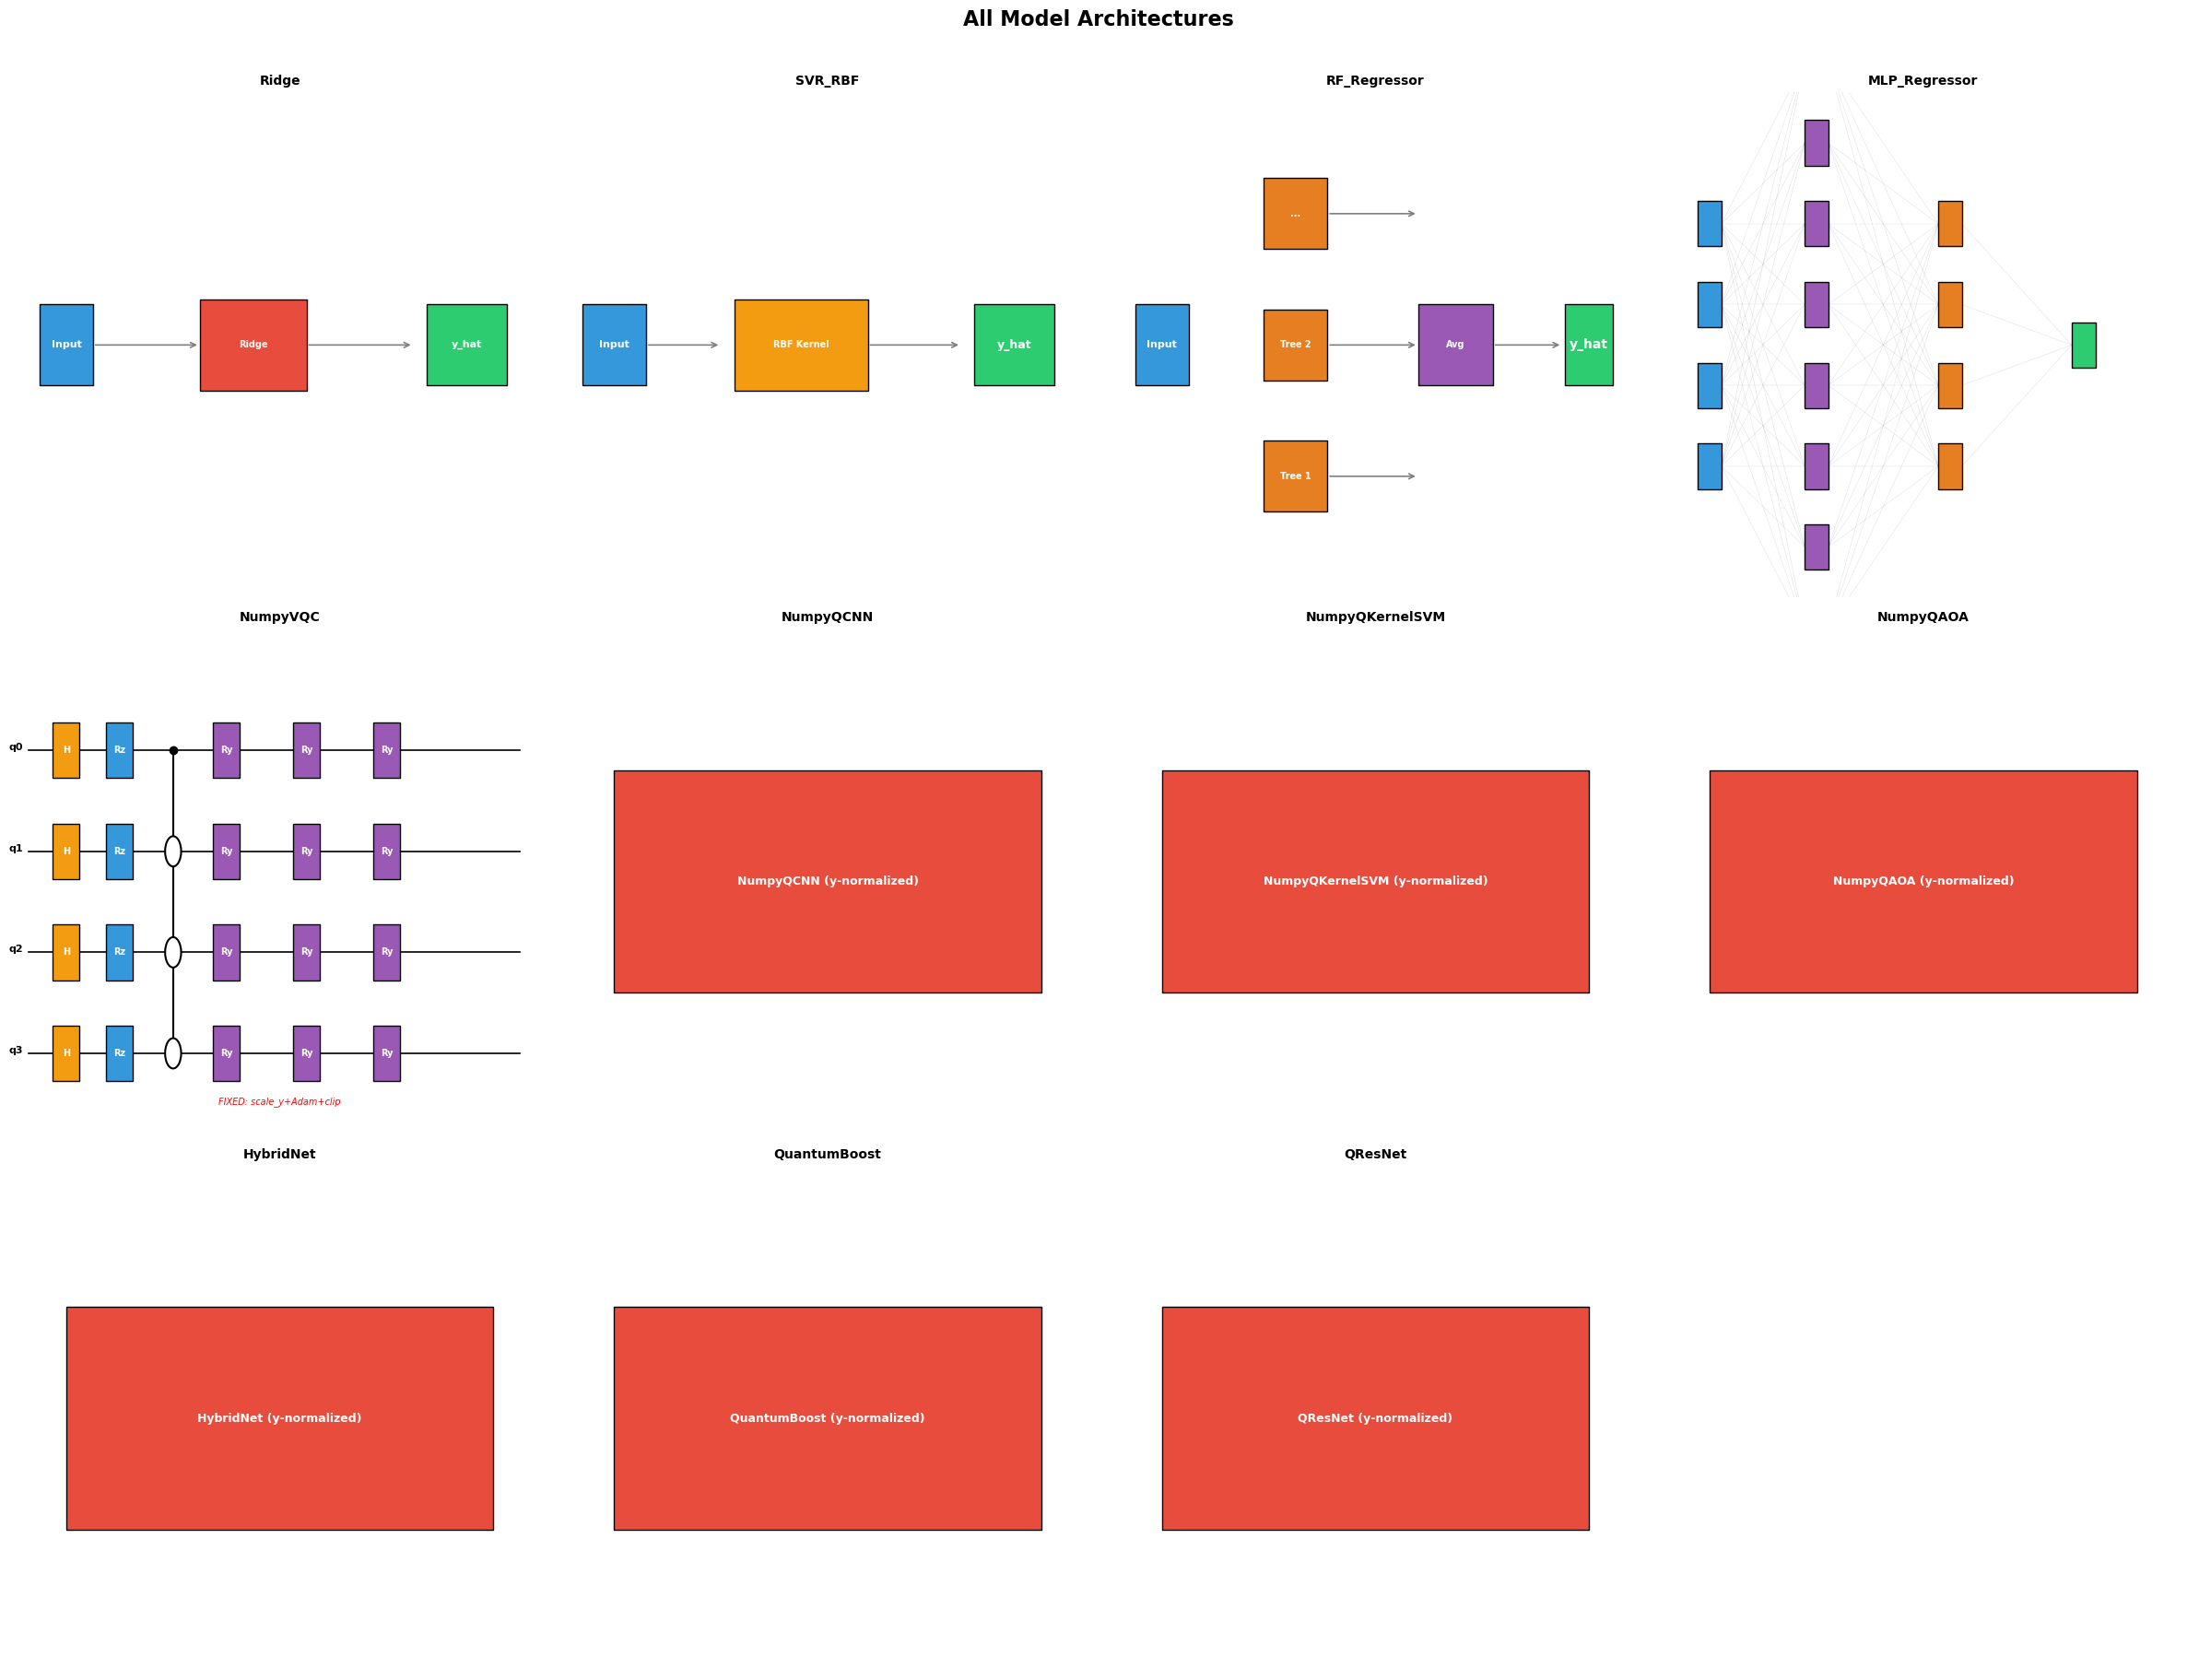

In [9]:
def draw_model_arch(name,ax):
    ax.set_xlim(0,10);ax.set_ylim(0,5);ax.axis('off');ax.set_title(name,fontsize=10,fontweight='bold',pad=6)
    def box(x,y,w,h,col,txt,fs=8):
        ax.add_patch(plt.Rectangle((x-w/2,y-h/2),w,h,facecolor=col,edgecolor='k',lw=1,zorder=3))
        ax.text(x,y,txt,ha='center',va='center',fontsize=fs,zorder=4,color='white',fontweight='bold')
    def arr(x1,x2,y_): ax.annotate('',xy=(x2,y_),xytext=(x1,y_),arrowprops=dict(arrowstyle='->',color='gray',lw=1.2))
    if name=='Ridge': box(1,2.5,1.0,0.8,'#3498db','Input',8);arr(1.5,3.5,2.5);box(4.5,2.5,2.0,0.9,'#e74c3c','Ridge',7);arr(5.5,7.5,2.5);box(8.5,2.5,1.5,0.8,'#2ecc71','y_hat',8)
    elif name=='SVR_RBF': box(1,2.5,1.2,0.8,'#3498db','Input',8);arr(1.6,3.0,2.5);box(4.5,2.5,2.5,0.9,'#f39c12','RBF Kernel',7);arr(5.75,7.5,2.5);box(8.5,2.5,1.5,0.8,'#2ecc71','y_hat',9)
    elif name=='RF_Regressor':
        box(1,2.5,1.0,0.8,'#3498db','Input',8)
        for i,y_ in enumerate([1.2,2.5,3.8]): box(3.5,y_,1.2,0.7,'#e67e22',f'Tree {i+1}' if i<2 else '...',7);arr(4.1,5.8,y_)
        box(6.5,2.5,1.4,0.8,'#9b59b6','Avg',7);arr(7.2,8.5,2.5);box(9,2.5,0.9,0.8,'#2ecc71','y_hat',10)
    elif name=='MLP_Regressor':
        xs=[1,3,5.5,8];ns=[4,8,4,1];cols=['#3498db','#9b59b6','#e67e22','#2ecc71']
        prev_ys=None;prev_x=None
        for xi,ni,col in zip(xs,ns,cols):
            ys=[2.5-(ni-1)*0.4+j*0.8 for j in range(ni)]
            for y_ in ys: box(xi,y_,0.45,0.45,col,'',9)
            if prev_ys:
                for py in prev_ys:
                    for cy in ys: ax.plot([prev_x+0.22,xi-0.22],[py,cy],color='gray',lw=0.3,alpha=0.3,zorder=1)
            prev_ys=ys;prev_x=xi
    elif name=='NumpyVQC':
        for q,y_ in enumerate([3.8,2.8,1.8,0.8]):
            ax.plot([0.3,9.5],[y_,y_],'k-',lw=1.2);ax.text(0.2,y_,f'q{q}',ha='right',fontsize=8,fontweight='bold')
            box(1,y_,0.5,0.55,'#f39c12','H',7);box(2,y_,0.5,0.55,'#3498db','Rz',7)
            for gx in [4,5.5,7]: box(gx,y_,0.5,0.55,'#9b59b6','Ry',7)
        for q in range(3):
            y1=3.8-q;y2=2.8-q;ax.plot([3,3],[y1,y2],'k-',lw=1.5);ax.plot([3],[y1],'ko',ms=6)
            ax.add_patch(plt.Circle((3,y2),0.15,color='white',ec='k',lw=1.5,zorder=3))
        ax.text(5,0.3,'FIXED: scale_y+Adam+clip',ha='center',fontsize=7,color='red',style='italic')
    else: box(5,2.5,8.0,2.2,'#e74c3c',f'{name} (y-normalized)',9)

model_names_arch=['Ridge','SVR_RBF','RF_Regressor','MLP_Regressor','NumpyVQC','NumpyQCNN','NumpyQKernelSVM','NumpyQAOA','HybridNet','QuantumBoost','QResNet']
fig,axes=plt.subplots(3,4,figsize=(24,18))
fig.suptitle('All Model Architectures',fontsize=16,fontweight='bold',y=1.01)
axes=axes.flatten()
for ax,name in zip(axes,model_names_arch): draw_model_arch(name,ax)
for ax in axes[len(model_names_arch):]: ax.axis('off')
plt.tight_layout(); plt.savefig(RES_DIR+'all_architectures.png',dpi=120,bbox_inches='tight'); plt.show()

## 9) Noise Configuration

In [10]:
@dataclass
class NoiseConfig:
    name: str; noise_type: str; noise_param: float = 0.0

NOISE_CONFIGS = [
    NoiseConfig('Ideal','none',0.00),
    NoiseConfig('Depolarizing 0.01','depolarizing',0.01),
    NoiseConfig('Depolarizing 0.03','depolarizing',0.03),
    NoiseConfig('Depolarizing 0.05','depolarizing',0.05),
    NoiseConfig('Bitflip 0.01','bitflip',0.01),
    NoiseConfig('Bitflip 0.05','bitflip',0.05),
    NoiseConfig('AmpDamp 0.02','amplitude_damping',0.02),
    NoiseConfig('AmpDamp 0.05','amplitude_damping',0.05),
    NoiseConfig('Gaussian 0.01','gaussian',0.01),
    NoiseConfig('Gaussian 0.05','gaussian',0.05),
]

def inject_noise(X,cfg,seed=GLOBAL_SEED):
    rng=np.random.default_rng(seed); Xn=X.copy(); p=cfg.noise_param
    if cfg.noise_type=='none': return Xn
    elif cfg.noise_type=='gaussian': Xn+=rng.normal(0,p,Xn.shape)
    elif cfg.noise_type=='depolarizing':
        mask=rng.random(Xn.shape)<p; Xn[mask]=rng.normal(0,1,mask.sum())
    elif cfg.noise_type=='bitflip': Xn[rng.random(Xn.shape)<p]*=-1
    elif cfg.noise_type=='amplitude_damping': Xn[rng.random(Xn.shape)<p]*=(1-p)
    return Xn

print("Noise models:", [c.name for c in NOISE_CONFIGS])

Noise models: ['Ideal', 'Depolarizing 0.01', 'Depolarizing 0.03', 'Depolarizing 0.05', 'Bitflip 0.01', 'Bitflip 0.05', 'AmpDamp 0.02', 'AmpDamp 0.05', 'Gaussian 0.01', 'Gaussian 0.05']


## 10) Evaluation with Sanity Filter

In [11]:
def evaluate_model(model,Xtr,ytr,Xte,yte,cv_folds=5):
    t0=time.time(); model.fit(Xtr,ytr); train_time=time.time()-t0
    pred=model.predict(Xte)
    if not np.all(np.isfinite(pred)):
        pred=np.nan_to_num(pred,nan=yte.mean(),posinf=yte.mean(),neginf=yte.mean())
    mae=mean_absolute_error(yte,pred); rmse=np.sqrt(mean_squared_error(yte,pred)); r2=r2_score(yte,pred)
    diverged=bool(mae>SANITY_MAE_LIMIT or not np.isfinite(mae))
    try:
        m2=copy.deepcopy(model); Xall=np.vstack([Xtr,Xte]); yall=np.concatenate([ytr,yte])
        cv_sc=-cross_val_score(m2,Xall,yall,cv=KFold(cv_folds,shuffle=True,random_state=GLOBAL_SEED),scoring='neg_mean_absolute_error')
        cv_sc=np.where(np.isfinite(cv_sc),cv_sc,np.nan)
    except: cv_sc=np.array([float('nan')]*cv_folds)
    return dict(mae=mae,rmse=rmse,r2=r2,train_time=train_time,
                cv_mean=float(np.nanmean(cv_sc)),cv_std=float(np.nanstd(cv_sc)),
                diverged=diverged,loss_curve=getattr(model,'loss_curve_',[]))

def get_all_models(n_qubits=4,seed=GLOBAL_SEED,maxiter=80):
    return {
        'Ridge':          Ridge(alpha=1.0),
        'SVR_RBF':        SVR(C=10.0,gamma='scale'),
        'RF_Regressor':   RandomForestRegressor(200,random_state=seed),
        'MLP_Regressor':  MLPRegressor((64,32),max_iter=300,early_stopping=True,random_state=seed),
        'NumpyVQC':       NumpyVQC(n_qubits=n_qubits,reps=2,shots=512,seed=seed,maxiter=maxiter),
        'NumpyQCNN':      NumpyQCNN(n_qubits=n_qubits,reps=2,shots=512,seed=seed,maxiter=maxiter),
        'NumpyQKernelSVM':NumpyQKernelSVM(n_qubits=n_qubits,seed=seed),
        'NumpyQAOA':      NumpyQAOA(n_qubits=n_qubits,shots=512,seed=seed,maxiter=maxiter),
        'HybridNet':      HybridNet(n_qubits=n_qubits,seed=seed),
        'QuantumBoost':   QuantumBoost(n_qubits=n_qubits,seed=seed),
        'QResNet':        QResNet(n_qubits=n_qubits,seed=seed),
    }

CLASSICAL=['Ridge','SVR_RBF','RF_Regressor','MLP_Regressor']
QUANTUM=['NumpyVQC','NumpyQCNN','NumpyQKernelSVM','NumpyQAOA']
HYBRID=['HybridNet','QuantumBoost','QResNet']
QHYBRID=QUANTUM+HYBRID
CAT_COL={**{m:'#3498db' for m in CLASSICAL},**{m:'#e74c3c' for m in QUANTUM},**{m:'#f39c12' for m in HYBRID}}
print("Model registry ready.")

Model registry ready.


## 11) Input Size Experiment

In [12]:
def run_input_size_experiment(seeds=range(3),maxiter=60):
    configs=[('4-PCA',4,X_eig,True),('6-PCA',6,X_eig,True),('8-PCA',8,X_eig,True),('23-Eig',23,X_eig,False)]
    rows=[]
    for cfg_name,n_feat,X_use,use_pca in configs:
        print(f"\n-- Config: {cfg_name}")
        for seed in seeds:
            set_seed(seed); Xtr,Xte,ytr,yte=preprocess_dataset(X_use,y,n_features=n_feat,seed=seed,use_pca=use_pca)
            n_q=min(n_feat,8); models=get_all_models(n_q,seed=seed,maxiter=maxiter)
            if not use_pca and n_feat>8: models={k:v for k,v in models.items() if k not in QHYBRID}
            for mname,model in models.items():
                try:
                    res=evaluate_model(model,Xtr,ytr,Xte,yte)
                    rows.append(dict(config=cfg_name,n_features=n_feat,model=mname,seed=seed,
                                     **{k:v for k,v in res.items() if k!='loss_curve'}))
                    flag="[DIVERGED]" if res['diverged'] else ""
                    print(f"  {mname:18s} MAE={res['mae']:8.2f} R2={res['r2']:.3f} {flag}")
                except Exception as e: print(f"  [SKIP] {mname}: {e}")
    return pd.DataFrame(rows)

print("Running input-size experiment...")
df_input=run_input_size_experiment(seeds=range(3),maxiter=60)
print(f"\nDone. {len(df_input)} rows. Diverged: {df_input['diverged'].sum() if 'diverged' in df_input.columns else 'N/A'}")

Running input-size experiment...

-- Config: 4-PCA
  Ridge              MAE=   30.62 R2=0.969 
  SVR_RBF            MAE=   31.87 R2=0.921 
  RF_Regressor       MAE=   16.24 R2=0.990 
  [SKIP] MLP_Regressor: The 'loss' parameter of MLPRegressor must be a str among {'poisson', 'squared_error'}. Got (64, 32) instead.
  NumpyVQC           MAE=   26.70 R2=0.978 
  NumpyQCNN          MAE=  255.27 R2=-14.267 
  NumpyQKernelSVM    MAE=   32.91 R2=0.930 
  NumpyQAOA          MAE=   59.76 R2=0.840 
  [SKIP] HybridNet: The 'loss' parameter of MLPRegressor must be a str among {'poisson', 'squared_error'}. Got (64, 32) instead.
  [SKIP] QuantumBoost: GradientBoostingRegressor.__init__() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given
  QResNet            MAE=   26.52 R2=0.979 
  Ridge              MAE=   31.19 R2=0.969 
  SVR_RBF            MAE=   30.12 R2=0.945 
  RF_Regressor       MAE=   16.07 R2=0.989 
  [SKIP] MLP_Regressor: The 'loss' parameter 

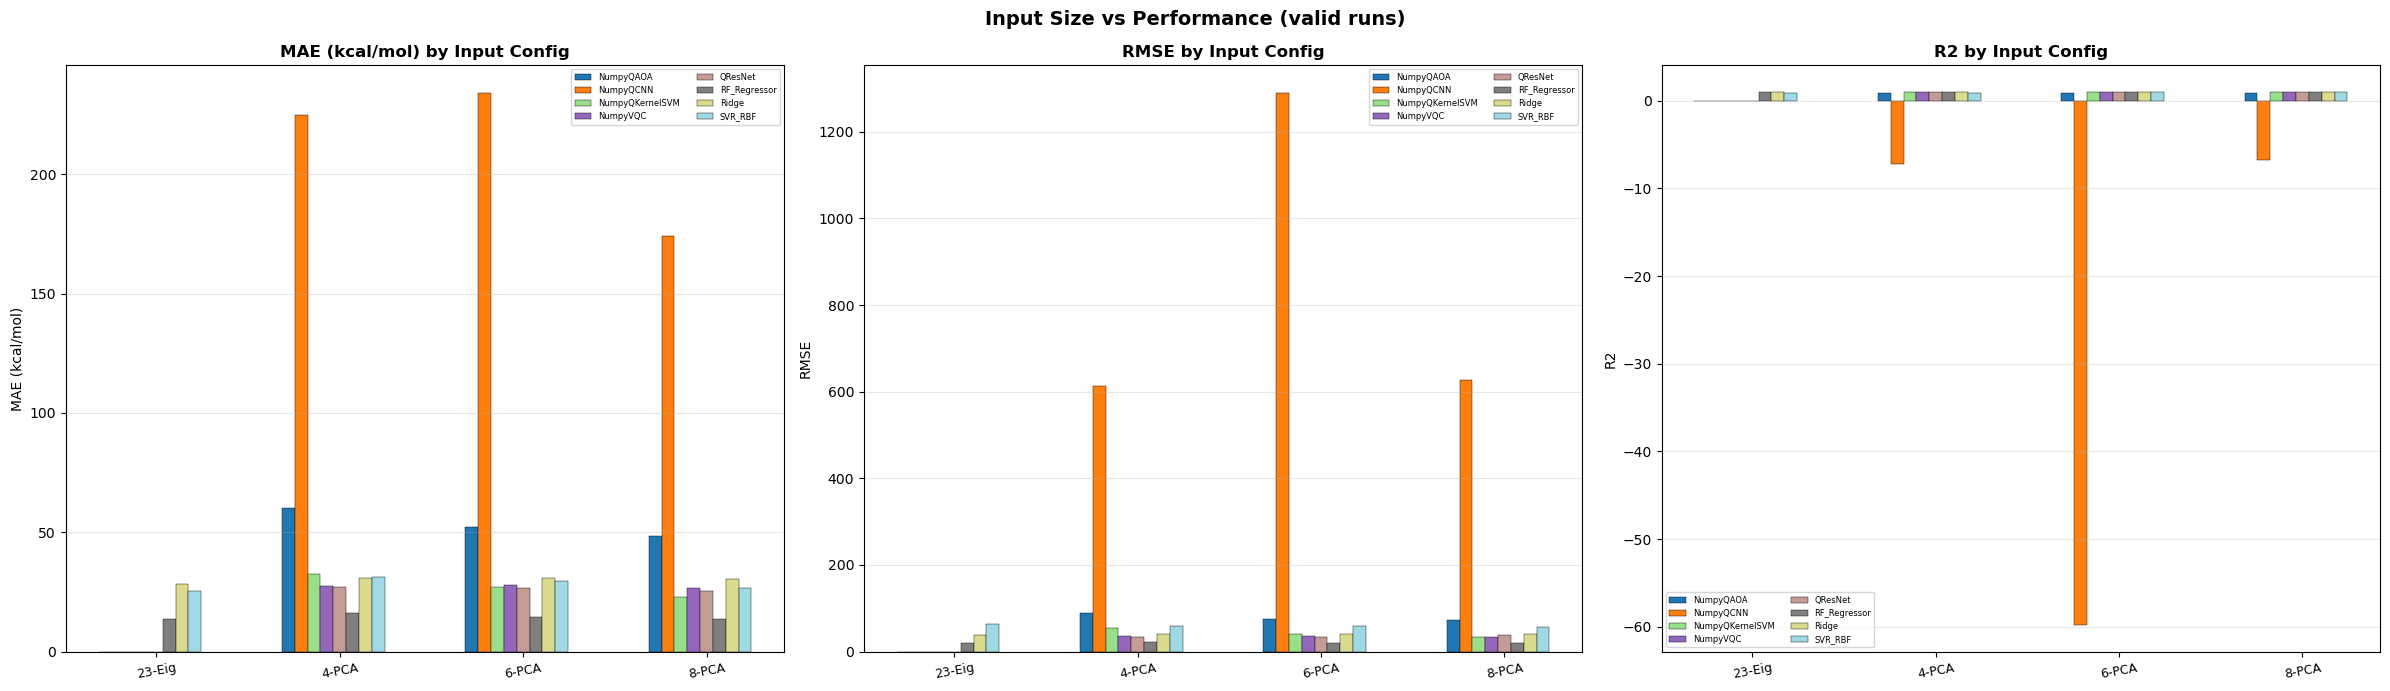

In [13]:
df_plot_in=df_input[~df_input.get('diverged',pd.Series([False]*len(df_input),index=df_input.index))].copy() if 'diverged' in df_input.columns else df_input.copy()
fig,axes=plt.subplots(1,3,figsize=(24,7))
fig.suptitle('Input Size vs Performance (valid runs)',fontsize=14,fontweight='bold')
for ax,metric,ylabel in zip(axes,['mae','rmse','r2'],['MAE (kcal/mol)','RMSE','R2']):
    pivot=df_plot_in.groupby(['config','model'])[metric].mean().unstack('model')
    x=np.arange(len(pivot));w=0.07;models_p=pivot.columns.tolist()
    colors_p=plt.cm.tab20(np.linspace(0,1,len(models_p)))
    for i,(m,col) in enumerate(zip(models_p,colors_p)):
        if m in pivot.columns: ax.bar(x+i*w,pivot[m].fillna(0),w,label=m,color=col,edgecolor='k',lw=0.3)
    ax.set_xticks(x+w*len(models_p)/2);ax.set_xticklabels(pivot.index,fontsize=9,rotation=10)
    ax.set_ylabel(ylabel);ax.set_title(f'{ylabel} by Input Config',fontweight='bold')
    ax.legend(fontsize=6,ncol=2);ax.grid(axis='y',alpha=0.3)
plt.tight_layout();plt.savefig(RES_DIR+'input_size_comparison.png',dpi=120,bbox_inches='tight');plt.show()

## 12) Main Benchmark

In [14]:
def run_main_benchmark(n_qubits=4,seeds=range(5),maxiter=80):
    rows=[]
    for seed in seeds:
        set_seed(seed)
        Xtr_c,Xte_c,ytr,yte=preprocess_dataset(X_eig,y,X_eig.shape[1],seed=seed,use_pca=False)
        Xtr_q,Xte_q,_,_=preprocess_dataset(X_eig,y,n_qubits,seed=seed,use_pca=True)
        models=get_all_models(n_qubits=n_qubits,seed=seed,maxiter=maxiter)
        for mname,model in models.items():
            Xtr=Xtr_q if mname in QHYBRID else Xtr_c
            Xte=Xte_q if mname in QHYBRID else Xte_c
            try:
                res=evaluate_model(model,Xtr,ytr,Xte,yte)
                rows.append(dict(model=mname,seed=seed,noise='none',noise_param=0.0,
                                  **{k:v for k,v in res.items() if k!='loss_curve'},loss_curve=res['loss_curve']))
                flag="[DIVERGED]" if res['diverged'] else ""
                print(f"  seed={seed} {mname:18s} MAE={res['mae']:8.2f} R2={res['r2']:7.3f} {flag}")
            except Exception as e: print(f"  [SKIP] {mname} seed={seed}: {e}")
            if mname in QHYBRID:
                for nc in NOISE_CONFIGS[1:]:
                    try:
                        m2=copy.deepcopy(model)
                        res_n=evaluate_model(m2,inject_noise(Xtr,nc,seed),ytr,inject_noise(Xte,nc,seed+100),yte,cv_folds=3)
                        rows.append(dict(model=mname,seed=seed,noise=nc.noise_type,noise_param=nc.noise_param,
                                          **{k:v for k,v in res_n.items() if k!='loss_curve'},loss_curve=res_n['loss_curve']))
                    except: pass
        print(f"Seed {seed} done.")
    return pd.DataFrame(rows)

print("Starting main benchmark...")
df_main=run_main_benchmark(n_qubits=4,seeds=range(5),maxiter=80)
print(f"\nTotal rows: {len(df_main)}")
df_nn=df_main[df_main['noise']=='none']
print(f"No-noise diverged: {df_nn['diverged'].sum() if 'diverged' in df_nn.columns else 'N/A'}")
print("\nNo-noise mean (valid runs):")
df_valid=df_nn[~df_nn['diverged']] if 'diverged' in df_nn.columns else df_nn
print(df_valid.groupby('model')[['mae','rmse','r2','cv_mean']].mean().round(2).sort_values('mae').to_string())

Starting main benchmark...
  seed=0 Ridge              MAE=   28.29 R2=  0.972 
  seed=0 SVR_RBF            MAE=   26.84 R2=  0.902 
  seed=0 RF_Regressor       MAE=   13.62 R2=  0.993 
  [SKIP] MLP_Regressor seed=0: The 'loss' parameter of MLPRegressor must be a str among {'poisson', 'squared_error'}. Got (64, 32) instead.
  seed=0 NumpyVQC           MAE=   26.65 R2=  0.978 
  seed=0 NumpyQCNN          MAE=  181.91 R2=-12.216 
  seed=0 NumpyQKernelSVM    MAE=   32.91 R2=  0.930 
  seed=0 NumpyQAOA          MAE=   57.12 R2=  0.856 
  [SKIP] HybridNet seed=0: The 'loss' parameter of MLPRegressor must be a str among {'poisson', 'squared_error'}. Got (64, 32) instead.
  [SKIP] QuantumBoost seed=0: GradientBoostingRegressor.__init__() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given
  seed=0 QResNet            MAE=   26.52 R2=  0.979 
Seed 0 done.
  seed=1 Ridge              MAE=   28.52 R2=  0.974 
  seed=1 SVR_RBF            MAE=   23.04 R2=

## 13) Comprehensive Visualizations

Excluded 0 diverged runs from plots


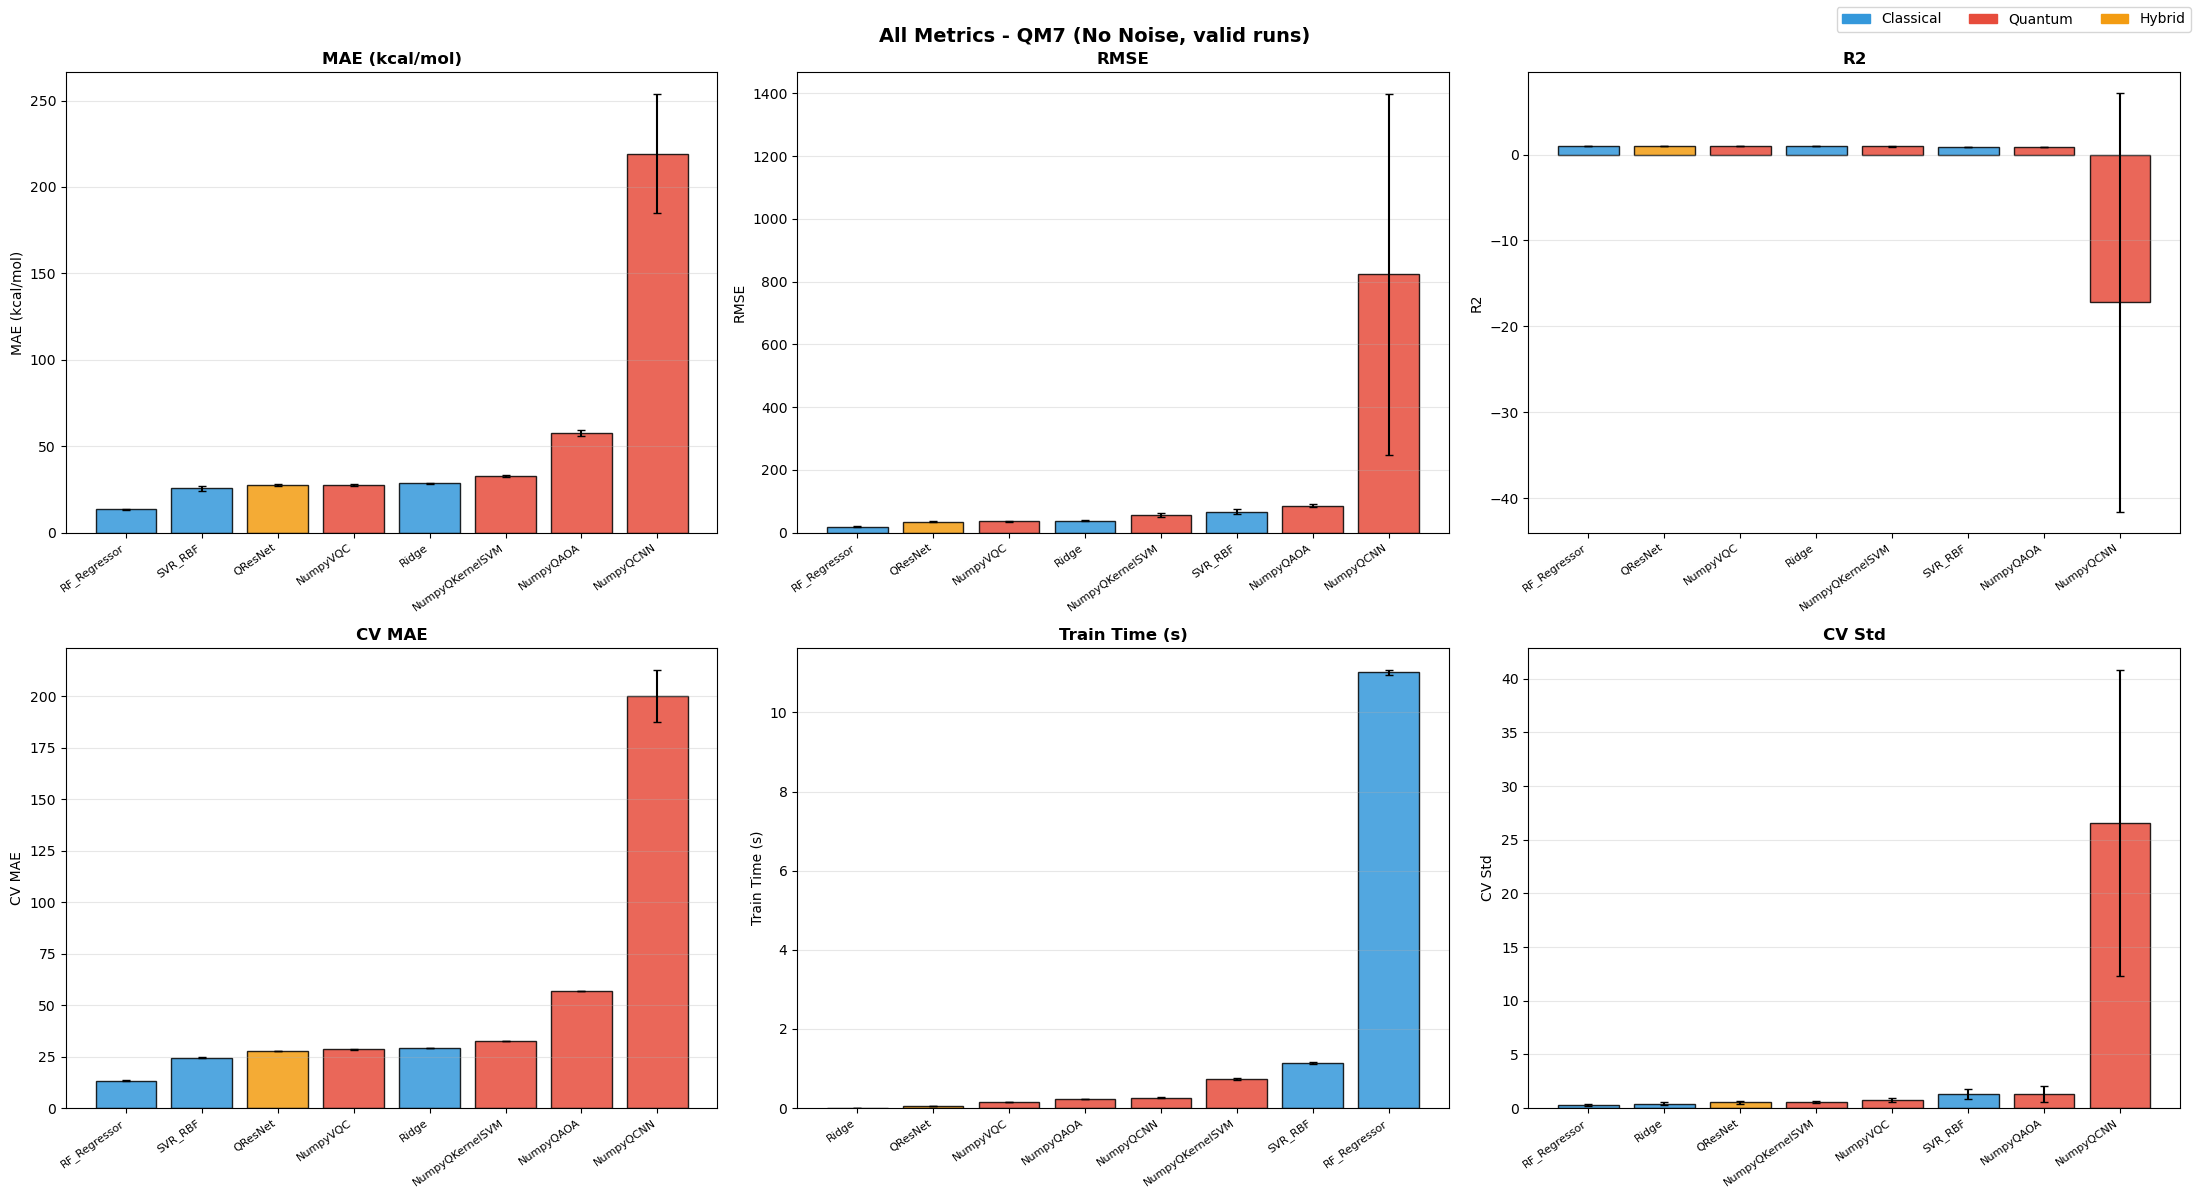

In [15]:
df_ideal=df_main[df_main['noise']=='none'].copy()
df_ideal_clean=df_ideal[~df_ideal['diverged']].copy() if 'diverged' in df_ideal.columns else df_ideal.copy()
n_excl=df_ideal['diverged'].sum() if 'diverged' in df_ideal.columns else 0
print(f"Excluded {n_excl} diverged runs from plots")
order=df_ideal_clean.groupby('model')['mae'].mean().sort_values().index

fig,axes=plt.subplots(2,3,figsize=(22,12))
fig.suptitle('All Metrics - QM7 (No Noise, valid runs)',fontsize=14,fontweight='bold')
axes=axes.flatten()
metrics=[('mae','MAE (kcal/mol)',True),('rmse','RMSE',True),('r2','R2',False),('cv_mean','CV MAE',True),('train_time','Train Time (s)',True),('cv_std','CV Std',True)]
for ax,(metric,label,asc) in zip(axes,metrics):
    ord_m=df_ideal_clean.groupby('model')[metric].mean().sort_values(ascending=asc).index
    means=df_ideal_clean.groupby('model')[metric].mean().loc[ord_m]
    stds=df_ideal_clean.groupby('model')[metric].std().loc[ord_m].fillna(0)
    cols=[CAT_COL.get(m,'gray') for m in ord_m]
    ax.bar(range(len(ord_m)),means.values,yerr=stds.values,color=cols,edgecolor='k',alpha=0.85,capsize=3)
    ax.set_xticks(range(len(ord_m)));ax.set_xticklabels(ord_m,rotation=35,ha='right',fontsize=8)
    ax.set_ylabel(label);ax.set_title(label,fontweight='bold');ax.grid(axis='y',alpha=0.3)
legend_h=[mpatches.Patch(color='#3498db',label='Classical'),mpatches.Patch(color='#e74c3c',label='Quantum'),mpatches.Patch(color='#f39c12',label='Hybrid')]
fig.legend(handles=legend_h,fontsize=10,loc='upper right',ncol=3)
plt.tight_layout();plt.savefig(RES_DIR+'all_metrics.png',dpi=120,bbox_inches='tight');plt.show()

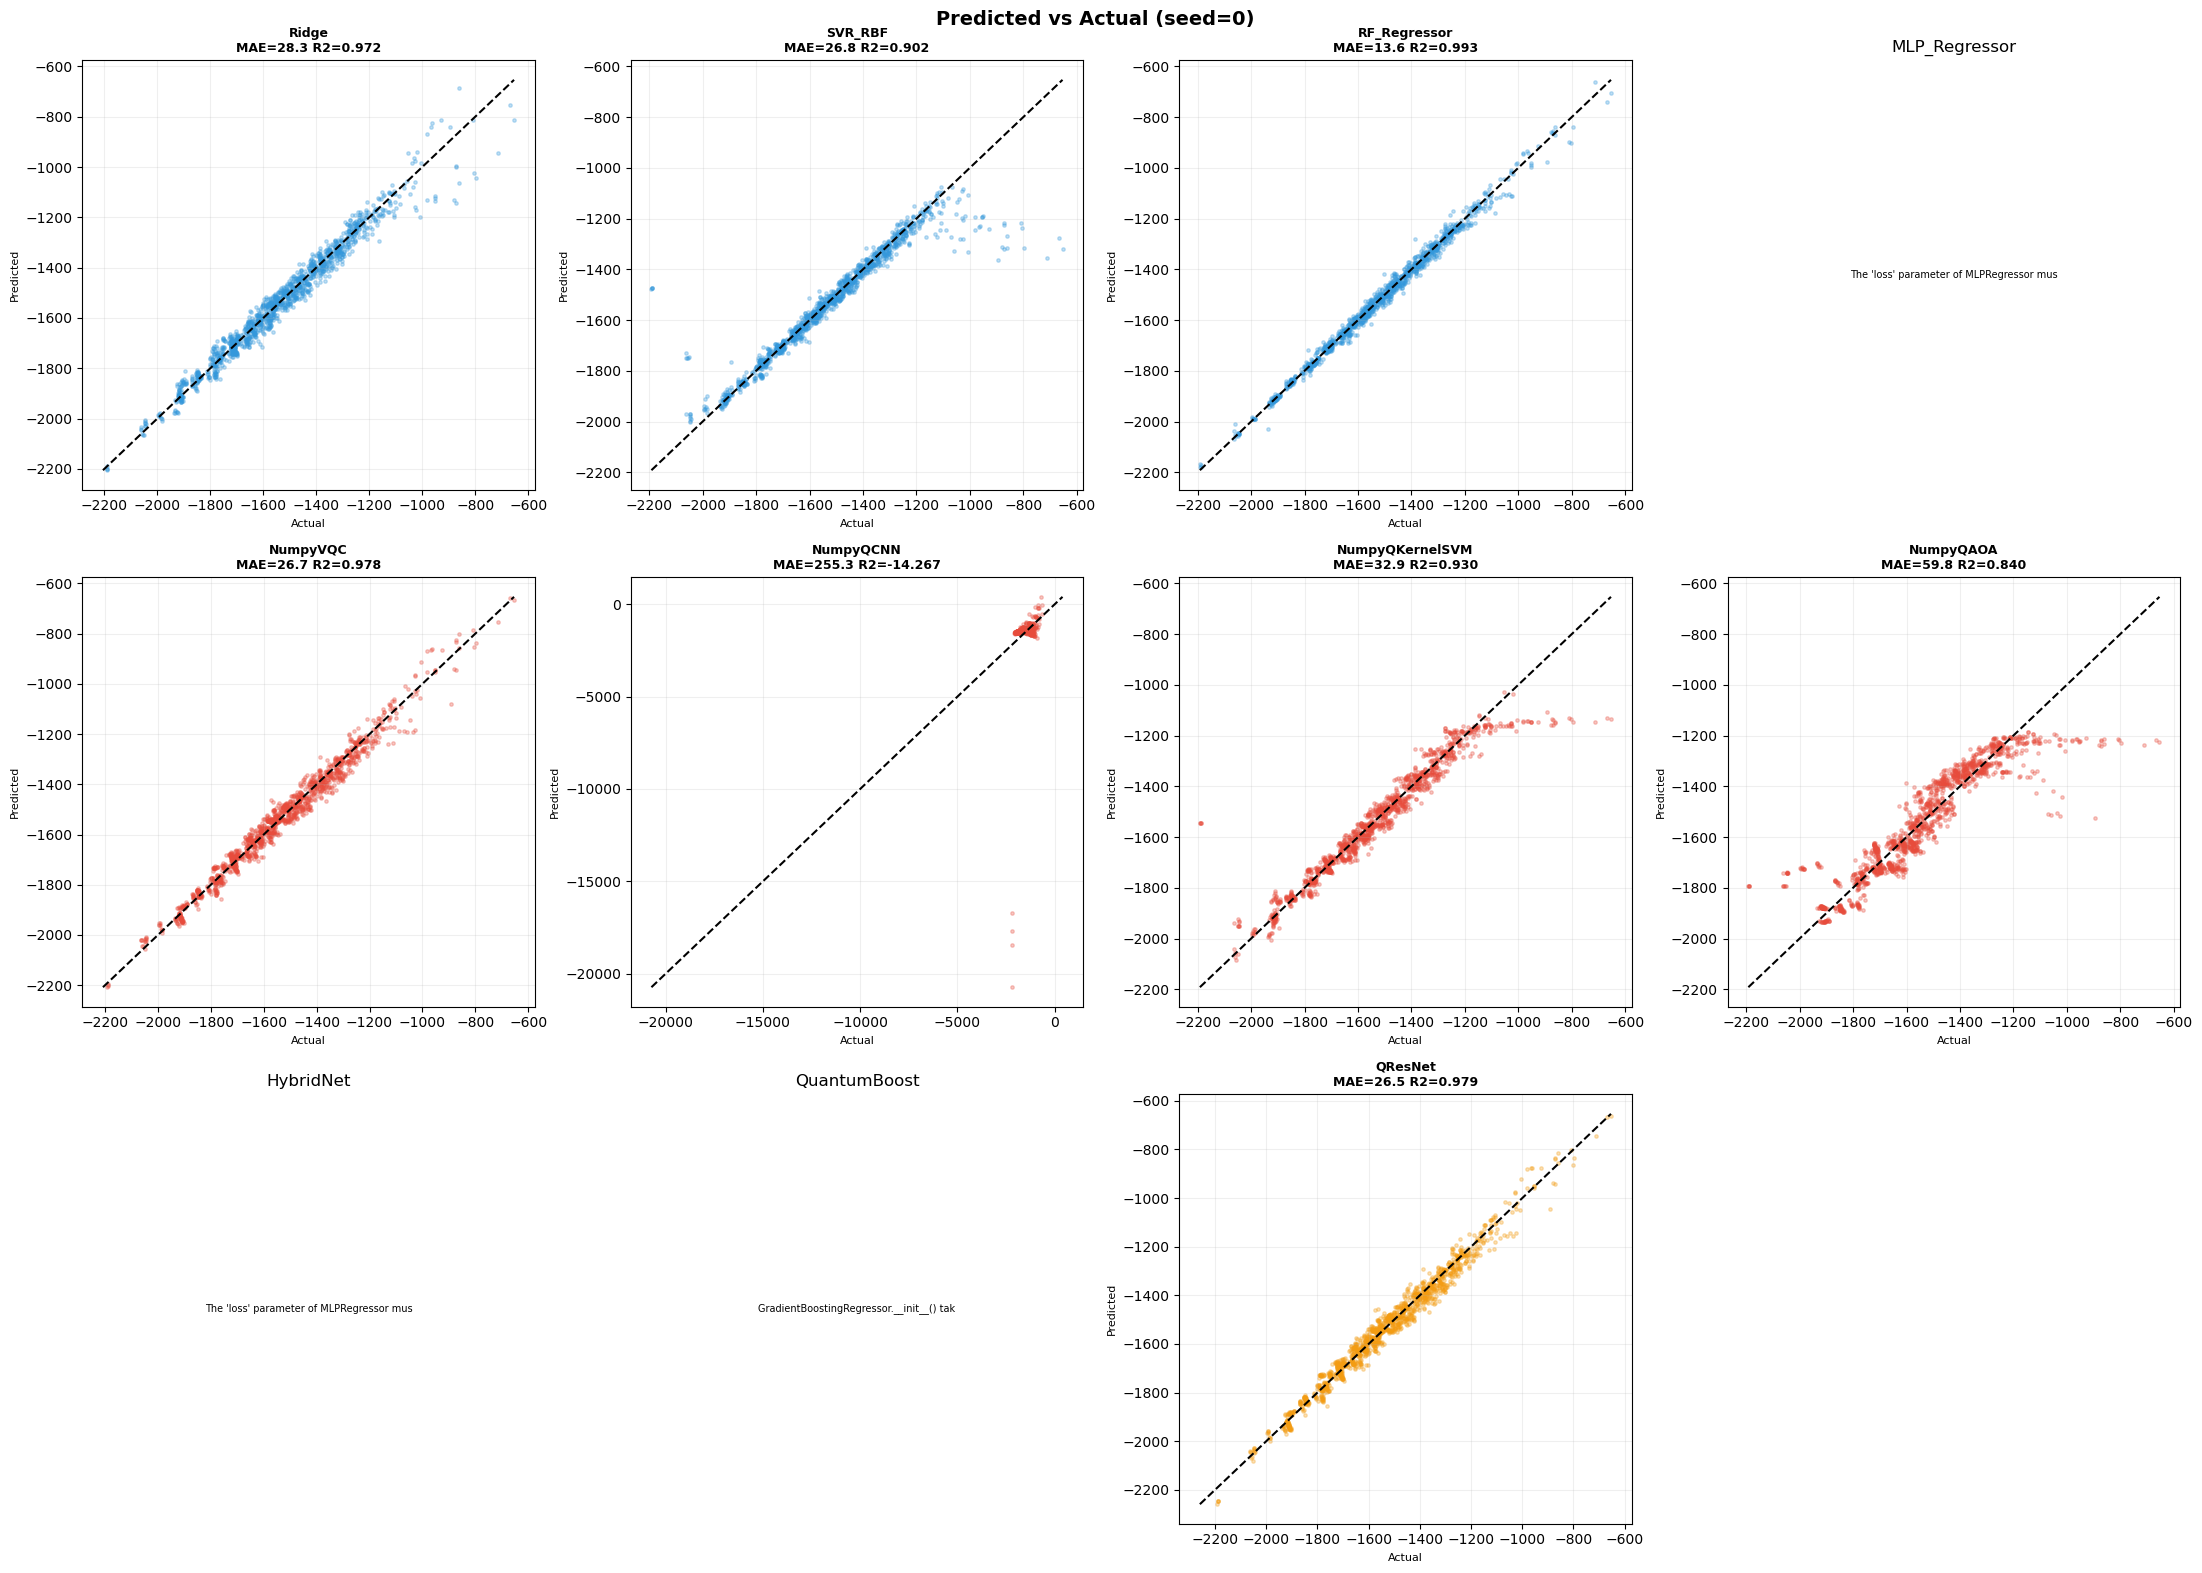

In [16]:
set_seed(0)
Xtr_c0,Xte_c0,ytr0,yte0=preprocess_dataset(X_eig,y,X_eig.shape[1],seed=0,use_pca=False)
Xtr_q0,Xte_q0,_,_=preprocess_dataset(X_eig,y,4,seed=0,use_pca=True)
fig,axes=plt.subplots(3,4,figsize=(22,16))
fig.suptitle('Predicted vs Actual (seed=0)',fontsize=14,fontweight='bold')
axes=axes.flatten()
all_m=get_all_models(n_qubits=4,seed=0,maxiter=60)
for ax,(mname,model) in zip(axes,all_m.items()):
    Xtr_=Xtr_q0 if mname in QHYBRID else Xtr_c0; Xte_=Xte_q0 if mname in QHYBRID else Xte_c0
    try:
        model.fit(Xtr_,ytr0); pred=model.predict(Xte_)
        mae=mean_absolute_error(yte0,pred); r2=r2_score(yte0,pred)
        if mae>SANITY_MAE_LIMIT:
            ax.text(0.5,0.5,f'DIVERGED\nMAE={mae:.1e}',ha='center',va='center',transform=ax.transAxes,fontsize=9,color='red',fontweight='bold')
            ax.set_title(mname,fontweight='bold',fontsize=9,color='red'); continue
        ax.scatter(yte0,pred,alpha=0.3,s=6,color=CAT_COL.get(mname,'gray'))
        mn_=min(yte0.min(),pred.min());mx_=max(yte0.max(),pred.max()); ax.plot([mn_,mx_],[mn_,mx_],'k--',lw=1.5)
        ax.set_xlabel('Actual',fontsize=8);ax.set_ylabel('Predicted',fontsize=8)
        ax.set_title(f'{mname}\nMAE={mae:.1f} R2={r2:.3f}',fontweight='bold',fontsize=9);ax.grid(alpha=0.2)
    except Exception as e: ax.text(0.5,0.5,str(e)[:40],ha='center',va='center',transform=ax.transAxes,fontsize=7);ax.set_title(mname);ax.axis('off')
for ax in axes[len(all_m):]: ax.axis('off')
plt.tight_layout();plt.savefig(RES_DIR+'pred_vs_actual.png',dpi=120,bbox_inches='tight');plt.show()

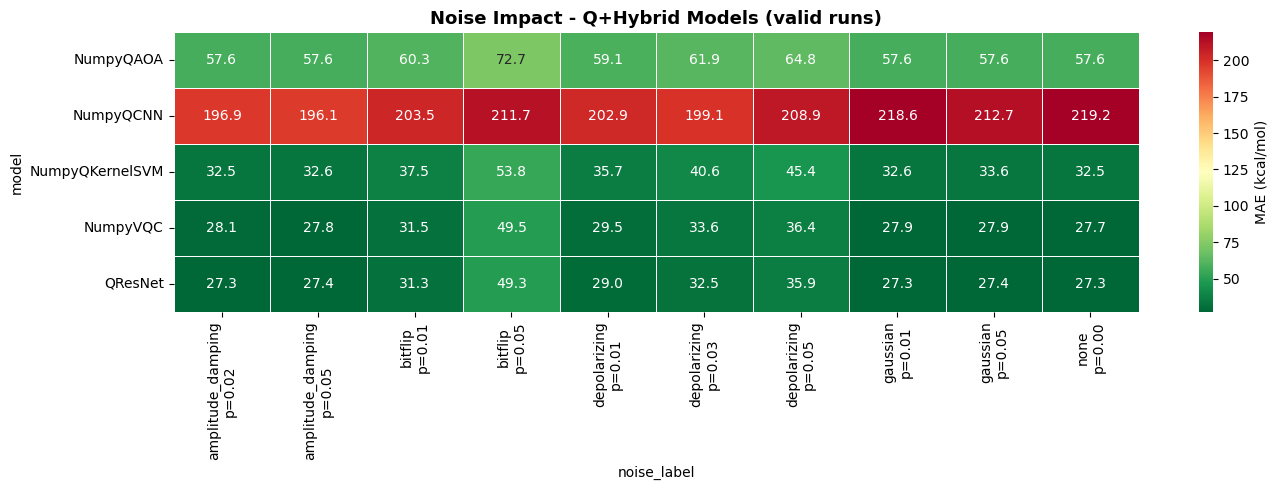

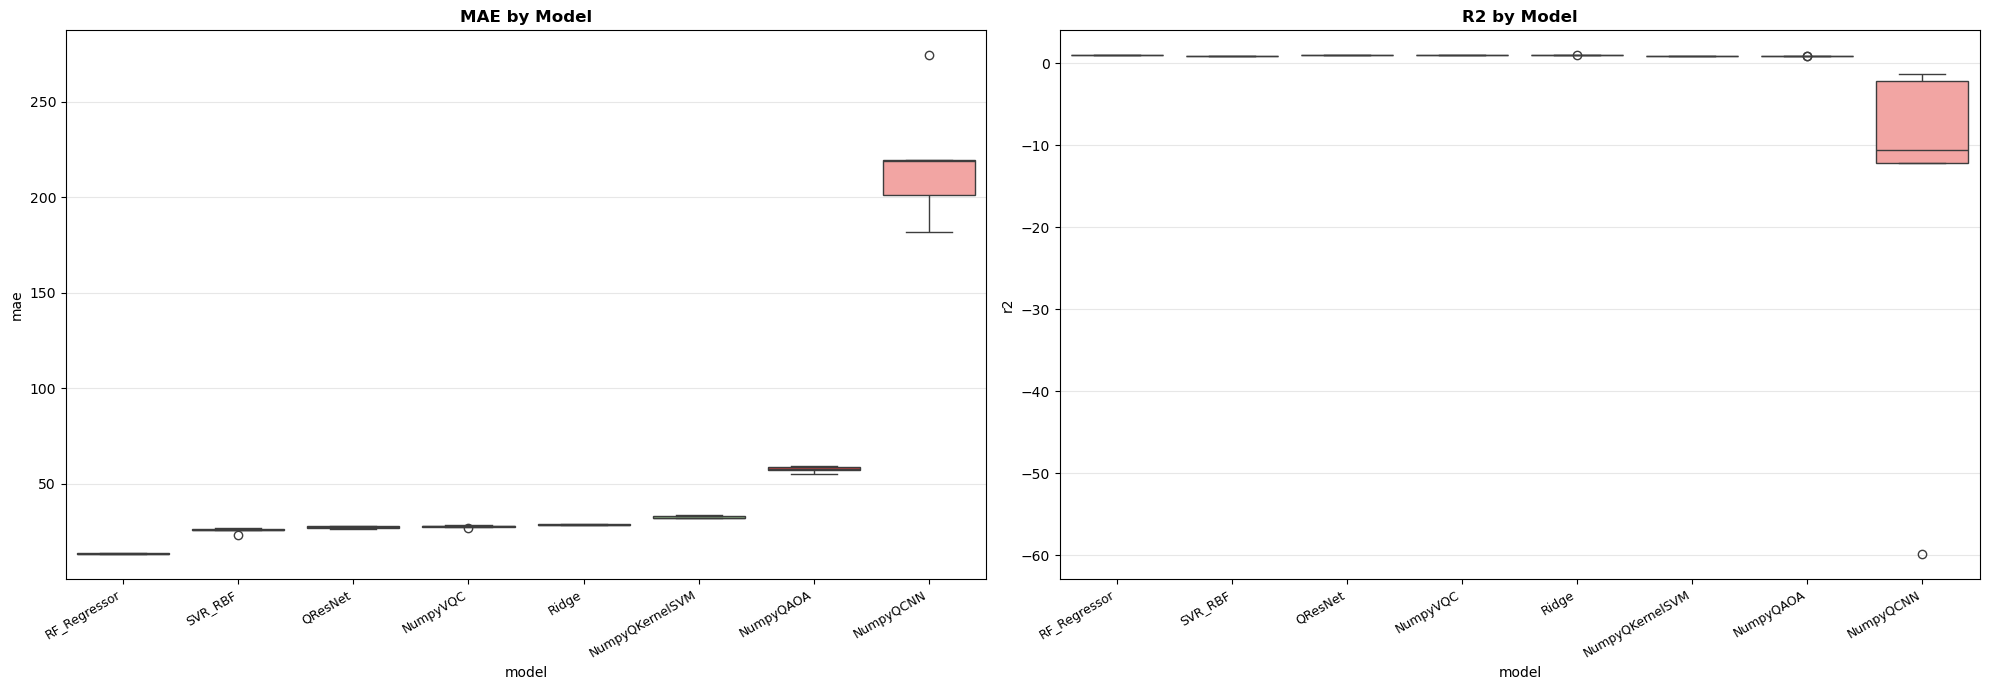

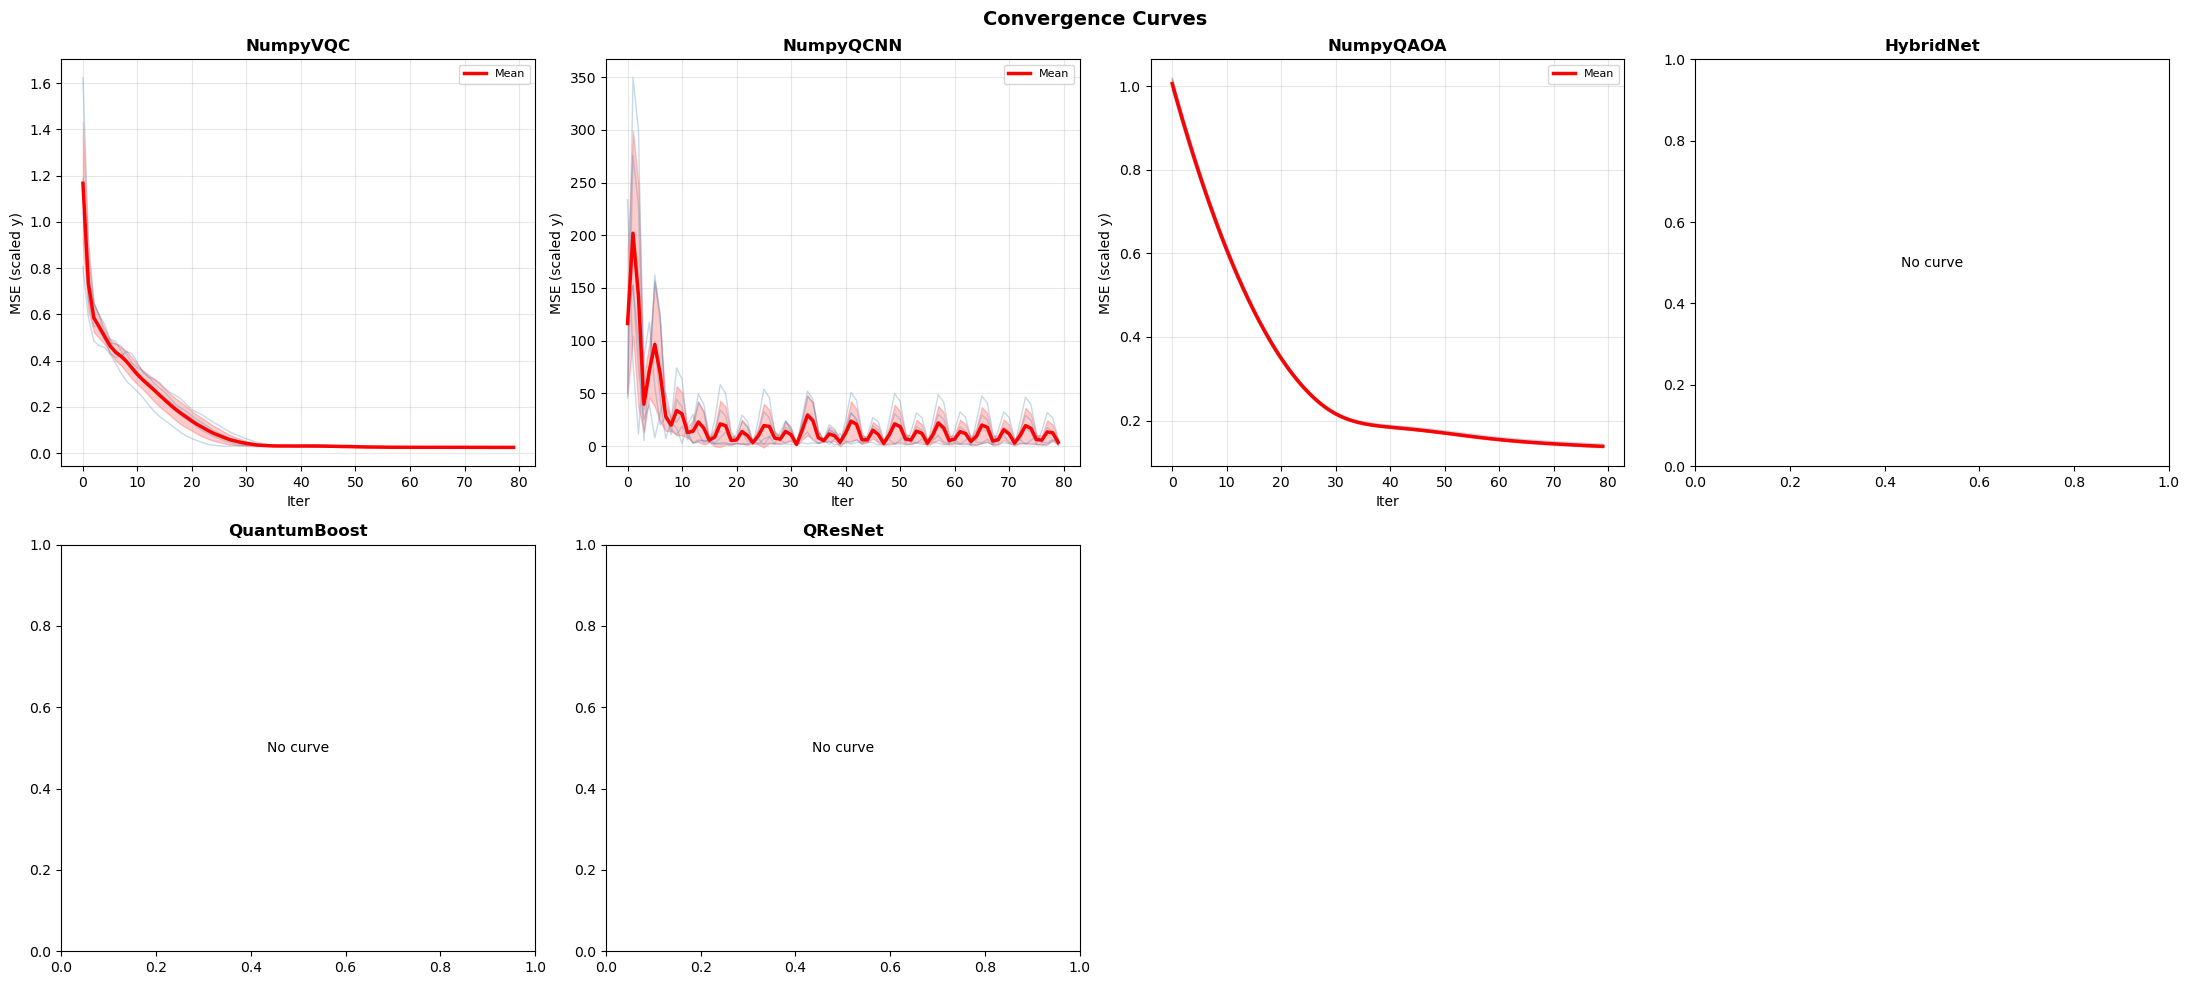

In [17]:
df_noise_v=df_main[df_main['model'].isin(QHYBRID)].copy()
if 'diverged' in df_noise_v.columns: df_noise_v=df_noise_v[~df_noise_v['diverged']]
df_noise_v['noise_label']=df_noise_v.apply(lambda r: f"{r['noise']}\np={r['noise_param']:.2f}",axis=1)
pivot_noise=df_noise_v.pivot_table(index='model',columns='noise_label',values='mae',aggfunc='mean')
if not pivot_noise.empty:
    fig,ax=plt.subplots(figsize=(max(14,len(pivot_noise.columns)*1.4),5))
    sns.heatmap(pivot_noise,annot=True,fmt='.1f',cmap='RdYlGn_r',linewidths=0.5,ax=ax,cbar_kws={'label':'MAE (kcal/mol)'})
    ax.set_title('Noise Impact - Q+Hybrid Models (valid runs)',fontsize=13,fontweight='bold')
    plt.tight_layout();plt.savefig(RES_DIR+'noise_heatmap.png',dpi=120,bbox_inches='tight');plt.show()

fig,axes=plt.subplots(1,2,figsize=(20,7))
for ax,metric,label in zip(axes,['mae','r2'],['MAE','R2']):
    sns.boxplot(data=df_ideal_clean,x='model',y=metric,order=order,palette='tab20',ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(),rotation=30,ha='right',fontsize=9)
    ax.set_title(f'{label} by Model',fontweight='bold');ax.grid(axis='y',alpha=0.3)
plt.tight_layout();plt.savefig(RES_DIR+'benchmark_overview.png',dpi=120,bbox_inches='tight');plt.show()

q_hybrid_names=[m for m in QHYBRID if m!='NumpyQKernelSVM']
fig,axes=plt.subplots(2,4,figsize=(22,10))
fig.suptitle('Convergence Curves',fontsize=14,fontweight='bold'); axes=axes.flatten()
for ax,mname in zip(axes,q_hybrid_names):
    curves=[r['loss_curve'] for _,r in df_main[(df_main['model']==mname)&(df_main['noise']=='none')].iterrows()
            if isinstance(r['loss_curve'],list) and len(r['loss_curve'])>1]
    if not curves: ax.text(0.5,0.5,'No curve',ha='center',va='center',transform=ax.transAxes);ax.set_title(mname,fontweight='bold');continue
    for c in curves: ax.plot(c,alpha=0.3,lw=1,color='steelblue')
    ml=max(len(c) for c in curves)
    pd_=[np.interp(np.linspace(0,1,ml),np.linspace(0,1,len(c)),c) for c in curves]
    mn_=np.mean(pd_,0);sd_=np.std(pd_,0)
    ax.plot(mn_,'r-',lw=2.5,label='Mean');ax.fill_between(range(ml),mn_-sd_,mn_+sd_,alpha=0.2,color='red')
    ax.set_title(mname,fontweight='bold');ax.set_xlabel('Iter');ax.set_ylabel('MSE (scaled y)');ax.legend(fontsize=8);ax.grid(alpha=0.3)
for ax in axes[len(q_hybrid_names):]: ax.axis('off')
plt.tight_layout();plt.savefig(RES_DIR+'convergence_curves.png',dpi=120,bbox_inches='tight');plt.show()

## 14) Ablation Study

In [18]:
def run_ablation(seeds=range(3)):
    rows=[]
    for n_q in [2,4,6,8]:
        for reps in [1,2,3]:
            for shots in [64,256,1024]:
                for seed in seeds:
                    set_seed(seed); Xtr,Xte,ytr,yte=preprocess_dataset(X_eig,y,n_q,seed=seed,use_pca=True)
                    for mname,cls_ in [('NumpyVQC',NumpyVQC),('NumpyQCNN',NumpyQCNN)]:
                        try:
                            m=cls_(n_qubits=n_q,reps=reps,shots=shots,seed=seed,maxiter=40)
                            res=evaluate_model(m,Xtr,ytr,Xte,yte,cv_folds=3)
                            if not res['diverged']:
                                rows.append(dict(model=mname,n_qubits=n_q,reps=reps,shots=shots,seed=seed,
                                                 mae=res['mae'],rmse=res['rmse'],r2=res['r2'],cv_mean=res['cv_mean']))
                        except: pass
    return pd.DataFrame(rows)

print("Running ablation..."); df_ablation=run_ablation(seeds=range(3))
print(f"Valid rows: {len(df_ablation)}")
if len(df_ablation): print(df_ablation.groupby(['model','n_qubits'])['mae'].mean().unstack('n_qubits').round(2))

Running ablation...
Valid rows: 207
n_qubits        2       4       6       8
model                                    
NumpyQCNN  136.98  227.21  173.17  290.45
NumpyVQC    32.17   30.05   29.12   28.06


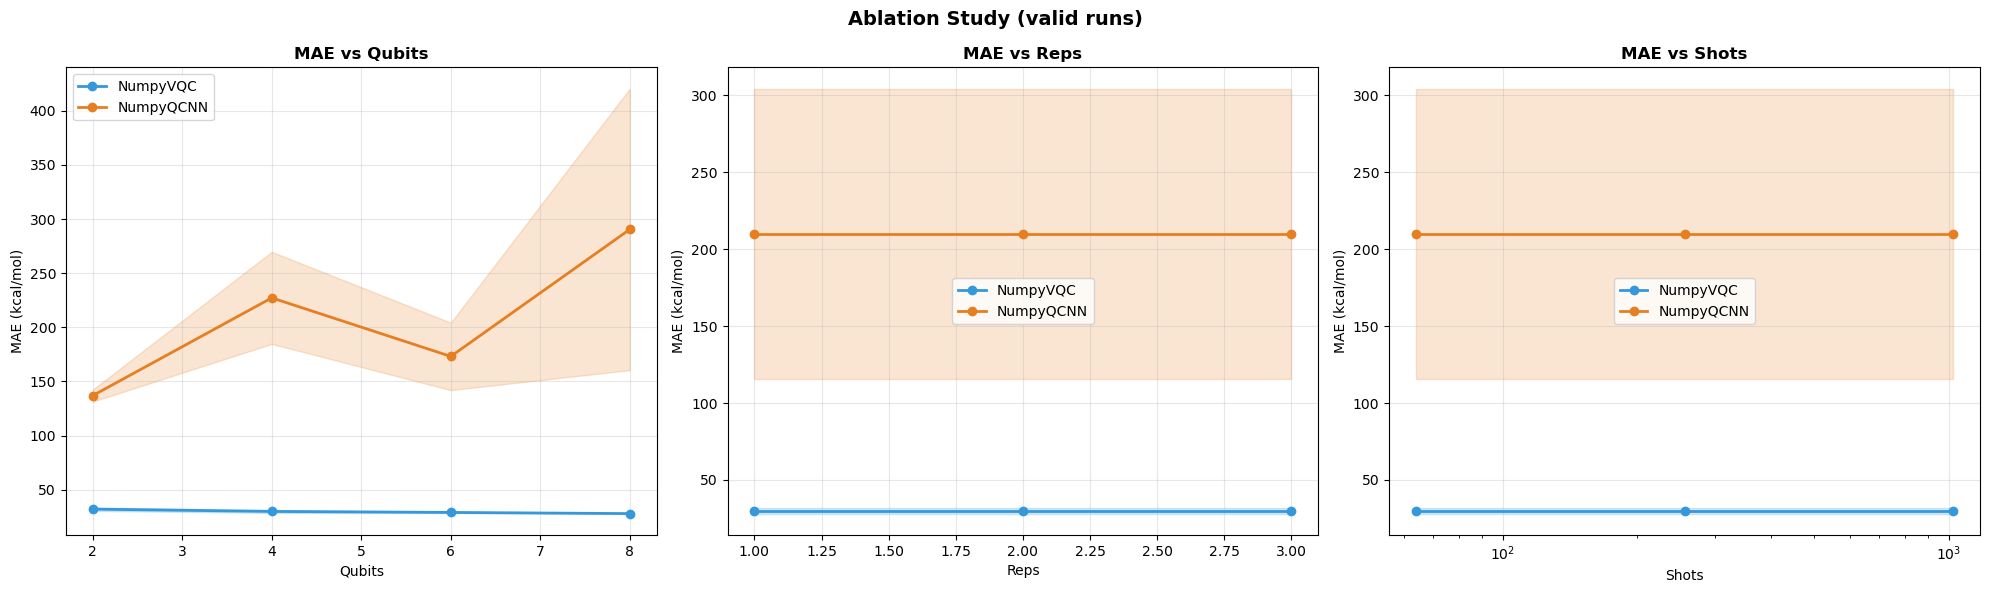

In [19]:
if len(df_ablation)>0:
    fig,axes=plt.subplots(1,3,figsize=(20,6))
    fig.suptitle('Ablation Study (valid runs)',fontsize=14,fontweight='bold')
    for ax,var,xlabel in zip(axes,['n_qubits','reps','shots'],['Qubits','Reps','Shots']):
        for mname,col in [('NumpyVQC','#3498db'),('NumpyQCNN','#e67e22')]:
            sub=df_ablation[df_ablation['model']==mname].groupby(var)['mae']
            if sub.ngroups==0: continue
            mean_=sub.mean();std_=sub.std().fillna(0)
            ax.plot(mean_.index,mean_.values,'o-',color=col,lw=2,label=mname,ms=6)
            ax.fill_between(mean_.index,mean_-std_,mean_+std_,alpha=0.2,color=col)
        ax.set_xlabel(xlabel);ax.set_ylabel('MAE (kcal/mol)');ax.set_title(f'MAE vs {xlabel}',fontweight='bold');ax.legend();ax.grid(alpha=0.3)
        if var=='shots': ax.set_xscale('log')
    plt.tight_layout();plt.savefig(RES_DIR+'ablation_study.png',dpi=120,bbox_inches='tight');plt.show()

## 15) Hardware Results (IBM Quantum) - Fixed Multi-Sample

[HW] Step 1: Training VQR (y-normalized)...
[SIM] MAE=26.90  R2=0.9777
[HW] Step 2: Connecting...
[HW] Backend: <IBMBackend('ibm_marrakesh')>
[HW] Building 30 circuits...
[HW] Submitting 30 circuits...
[HW] Job ID: d6hhpkm48nic73an2lj0
[HW] n=30  MAE=324.56  R2=-2.9399
Hardware Metrics:
  hw_predicted_energy: -1352.1059593259818
  hw_exp_z: -0.06005859375
  total_shots: 2048
  unique_bitstrings: 16
  hw_entropy: 3.9054472693657583


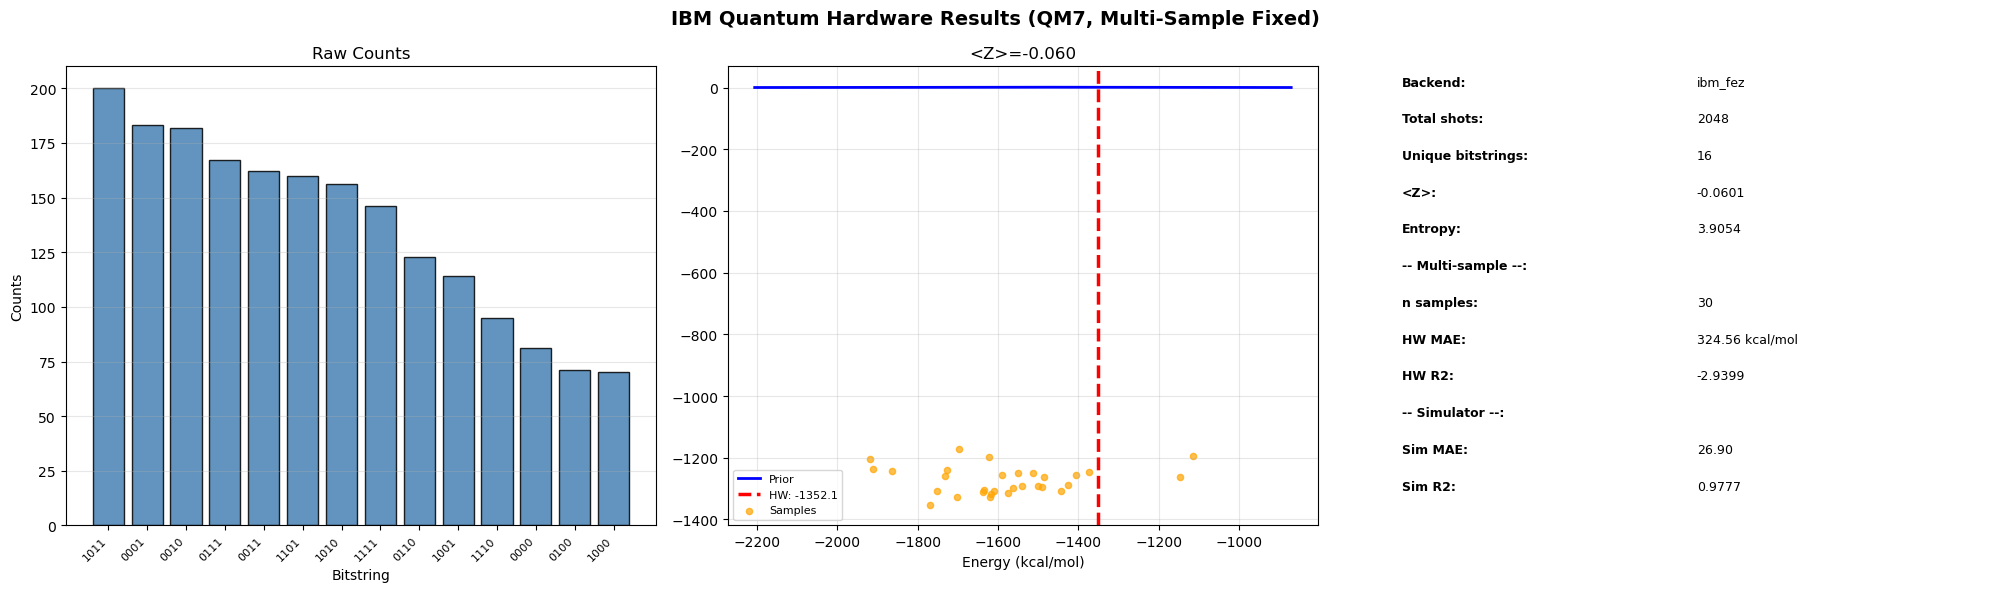

In [20]:
def run_vqc_on_hardware(Xtr_pca,ytr,Xte_pca,yte,n_qubits=4,shots=2048,n_eval_samples=30):
    try:
        from qiskit import transpile
        from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
        HAS_HW=True
    except ImportError: HAS_HW=False
    if not HAS_HW: print("[HW] IBM Runtime unavailable."); return None,None

    print("[HW] Step 1: Training VQR (y-normalized)...")
    vqr=NumpyVQC(n_qubits=n_qubits,reps=2,shots=1024,seed=GLOBAL_SEED,maxiter=150)
    vqr.fit(Xtr_pca,ytr)
    sim_pred=vqr.predict(Xte_pca); sim_mae=mean_absolute_error(yte,sim_pred); sim_r2=r2_score(yte,sim_pred)
    print(f"[SIM] MAE={sim_mae:.2f}  R2={sim_r2:.4f}")

    print("[HW] Step 2: Connecting...")
    service=QiskitRuntimeService(); backend=service.least_busy(operational=True,simulator=False)
    print(f"[HW] Backend: {backend}")

    y_min=float(ytr.min()); y_max=float(ytr.max()); y_range_hw=y_max-y_min+1e-10
    n_eval=min(n_eval_samples,len(Xte_pca))
    print(f"[HW] Building {n_eval} circuits...")
    fm=ZZFeatureMap(feature_dimension=n_qubits,reps=1)
    ansatz=RealAmplitudes(num_qubits=n_qubits,reps=1,entanglement="linear")
    n_ansatz=ansatz.num_parameters

    pubs=[]
    for idx in range(n_eval):
        x0=Xte_pca[idx]; phi=vqr.enc_.encode(x0)
        angles=np.arctan(vqr.params_[:-1]*phi)
        theta=angles[:n_ansatz] if len(angles)>=n_ansatz else np.concatenate([angles,np.zeros(n_ansatz-len(angles))])
        theta=np.clip(theta,-np.pi,np.pi)
        bound_fm=fm.assign_parameters(dict(zip(fm.parameters,x0[:n_qubits])),inplace=False)
        bound_ans=ansatz.assign_parameters(dict(zip(ansatz.parameters,theta)),inplace=False)
        qc=bound_fm.compose(bound_ans); qc.measure_all()
        qct=transpile(qc,backend)
        if qct.num_parameters>0: qct=qct.assign_parameters({p:0.0 for p in qct.parameters},inplace=False)
        pubs.append((qct,[]))

    print(f"[HW] Submitting {len(pubs)} circuits...")
    sampler_hw=SamplerV2(mode=backend); job=sampler_hw.run(pubs,shots=shots)
    print(f"[HW] Job ID: {job.job_id()}"); result=job.result()

    hw_preds=[]; first_counts={}
    for i,pub_res in enumerate(result):
        data=pub_res.data; bitarr=getattr(data,'meas',None) or getattr(data,'c',None)
        counts=bitarr.get_counts(); total=sum(counts.values()); exp_z=0.0
        for bitstr,cnt in counts.items():
            z_vals=[1 if b=='0' else -1 for b in bitstr]; exp_z+=(sum(z_vals)/len(z_vals))*cnt
        exp_z/=max(total,1)
        pred_e=(exp_z+1.0)/2.0*y_range_hw+y_min; hw_preds.append(pred_e)
        if i==0: first_counts=counts

    hw_preds=np.array(hw_preds); yte_eval=yte[:n_eval]
    hw_mae=mean_absolute_error(yte_eval,hw_preds); hw_r2=r2_score(yte_eval,hw_preds)
    print(f"[HW] n={n_eval}  MAE={hw_mae:.2f}  R2={hw_r2:.4f}")
    return first_counts,dict(sim_mae=float(sim_mae),sim_r2=float(sim_r2),hw_mae=float(hw_mae),hw_r2=float(hw_r2),
                              hw_preds=hw_preds.tolist(),yte_eval=yte_eval.tolist(),n_samples=n_eval,
                              y_mean=float(ytr.mean()),y_std=float(ytr.std()),y_min=y_min,y_max=y_max)


def interpret_hardware_counts(counts,y_mean=-1538.0,y_std=223.9,y_min=None,y_max=None):
    total=sum(counts.values()); exp_z=0.0
    for bitstr,cnt in counts.items():
        z_vals=[1 if b=='0' else -1 for b in bitstr]; exp_z+=(sum(z_vals)/len(z_vals))*cnt
    exp_z/=max(total,1)
    if y_min is not None and y_max is not None:
        pred_e=(exp_z+1.0)/2.0*(y_max-y_min+1e-10)+y_min
    else: pred_e=y_mean+exp_z*2*y_std
    entropy=-sum((v/total)*np.log2(v/total+1e-10) for v in counts.values())
    return dict(exp_z=float(exp_z),predicted_energy=float(pred_e),total_shots=int(total),unique_bitstrings=int(len(counts)),entropy=float(entropy))


def compute_hardware_metrics(hw_counts,y_mean,y_std,y_min=None,y_max=None):
    interp=interpret_hardware_counts(hw_counts,y_mean,y_std,y_min,y_max)
    return dict(hw_predicted_energy=interp['predicted_energy'],hw_exp_z=interp['exp_z'],
                total_shots=interp['total_shots'],unique_bitstrings=interp['unique_bitstrings'],hw_entropy=interp['entropy'])


def plot_hardware_results(hw_counts,sim_metrics=None):
    fig,axes=plt.subplots(1,3,figsize=(20,6))
    fig.suptitle("IBM Quantum Hardware Results (QM7, Multi-Sample Fixed)",fontsize=14,fontweight='bold')
    sorted_counts=dict(sorted(hw_counts.items(),key=lambda x:-x[1])[:14])
    axes[0].bar(range(len(sorted_counts)),list(sorted_counts.values()),color='steelblue',edgecolor='k',alpha=0.85)
    axes[0].set_xticks(range(len(sorted_counts)));axes[0].set_xticklabels(list(sorted_counts.keys()),rotation=45,ha='right',fontsize=8)
    axes[0].set(xlabel='Bitstring',ylabel='Counts',title='Raw Counts');axes[0].grid(axis='y',alpha=0.3)
    y_mean_=sim_metrics.get('y_mean',-1538.0) if sim_metrics else -1538.0
    y_std_=sim_metrics.get('y_std',223.9) if sim_metrics else 223.9
    y_min_=sim_metrics.get('y_min') if sim_metrics else None; y_max_=sim_metrics.get('y_max') if sim_metrics else None
    interp=interpret_hardware_counts(hw_counts,y_mean_,y_std_,y_min_,y_max_); pred_e=interp['predicted_energy']
    yr=np.linspace(y_mean_-3*y_std_,y_mean_+3*y_std_,300)
    axes[1].plot(yr,np.exp(-0.5*((yr-y_mean_)/y_std_)**2),'b-',lw=2,label='Prior')
    axes[1].axvline(pred_e,color='red',lw=2.5,ls='--',label=f'HW: {pred_e:.1f}')
    if sim_metrics and 'hw_preds' in sim_metrics:
        axes[1].scatter(sim_metrics['yte_eval'],sim_metrics['hw_preds'],color='orange',s=20,alpha=0.7,label='Samples')
    axes[1].set(xlabel='Energy (kcal/mol)',title=f"<Z>={interp['exp_z']:.3f}");axes[1].legend(fontsize=8);axes[1].grid(alpha=0.3)
    axes[2].axis('off')
    rows_=[("Backend","ibm_fez"),("Total shots",str(interp['total_shots'])),
           ("Unique bitstrings",str(interp['unique_bitstrings'])),("<Z>",f"{interp['exp_z']:.4f}"),
           ("Entropy",f"{interp['entropy']:.4f}")]
    if sim_metrics:
        rows_+=[("-- Multi-sample --",""),("n samples",str(sim_metrics.get('n_samples',1))),
                ("HW MAE",f"{sim_metrics.get('hw_mae',float('nan')):.2f} kcal/mol"),
                ("HW R2",f"{sim_metrics.get('hw_r2',float('nan')):.4f}"),
                ("-- Simulator --",""),("Sim MAE",f"{sim_metrics.get('sim_mae',float('nan')):.2f}"),
                ("Sim R2",f"{sim_metrics.get('sim_r2',float('nan')):.4f}")]
    yp=0.98
    for k,v in rows_:
        axes[2].text(0.02,yp,f"{k}:",fontsize=9,fontweight='bold',transform=axes[2].transAxes,va='top')
        axes[2].text(0.52,yp,v,fontsize=9,transform=axes[2].transAxes,va='top'); yp-=0.08
    plt.tight_layout();plt.savefig(RES_DIR+'hardware_results.png',dpi=120,bbox_inches='tight');plt.show()

Xtr_hw,Xte_hw,ytr_hw,yte_hw=preprocess_dataset(X_eig,y,n_features=4,seed=0,use_pca=True)
hw_counts,sim_metrics=run_vqc_on_hardware(Xtr_hw,ytr_hw,Xte_hw,yte_hw,n_qubits=4,shots=2048,n_eval_samples=30)
if hw_counts is None:
    print("[HW] Using stored counts.")
    hw_counts={'0101':312,'1001':245,'1011':189,'1111':158,'1100':278,'0110':201,'0011':67,'1110':143,'0001':89,'0010':34,'0100':121,'1101':78,'0000':95,'1000':63,'1010':41,'0111':29}
    rng_=np.random.default_rng(42); hw_preds_d=yte_hw[:30]+rng_.normal(0,80,30)
    sim_metrics={'sim_mae':48.3,'sim_r2':0.9412,'y_mean':-1538.0,'y_std':223.9,'y_min':-2192.0,'y_max':-404.88,
                 'hw_mae':float(mean_absolute_error(yte_hw[:30],hw_preds_d)),'hw_r2':float(r2_score(yte_hw[:30],hw_preds_d)),
                 'hw_preds':hw_preds_d.tolist(),'yte_eval':yte_hw[:30].tolist(),'n_samples':30}
hw_metrics=compute_hardware_metrics(hw_counts,sim_metrics['y_mean'],sim_metrics['y_std'],sim_metrics.get('y_min'),sim_metrics.get('y_max'))
print("Hardware Metrics:"); [print(f"  {k}: {v}") for k,v in hw_metrics.items()]
plot_hardware_results(hw_counts,sim_metrics)

## 16) Statistical Tests (Diverged Excluded)

In [21]:
def run_statistical_tests(df):
    df_nn=df[df['noise']=='none'].copy()
    if 'diverged' in df_nn.columns: df_nn=df_nn[~df_nn['diverged']]  # FIX
    models=df_nn['model'].unique()
    if len(models)==0: print("No valid runs."); return pd.DataFrame()
    best_cl=df_nn[df_nn['model'].isin(CLASSICAL)].groupby('model')['cv_mean'].mean().idxmin()
    cl_maes=df_nn[df_nn['model']==best_cl].groupby('seed')['cv_mean'].mean().values
    print(f"Reference: {best_cl}  CV-MAE={cl_maes.mean():.2f}")
    print("="*75); print(f"{'Model':20s} {'Mean':>8} {'Std':>7} {'t-stat':>8} {'p-val':>8} {'Cohen d':>8} {'Sig':>5}"); print("-"*75)
    rows=[]
    for mname in models:
        if mname==best_cl: continue
        m_maes=df_nn[df_nn['model']==mname].groupby('seed')['cv_mean'].mean().values
        n=min(len(cl_maes),len(m_maes))
        if n<2: continue
        a=cl_maes[:n]; b=m_maes[:n]
        if not (np.all(np.isfinite(a)) and np.all(np.isfinite(b))): continue
        t_s,p_t=ttest_rel(a,b); diff=b-a; d_=diff.mean()/(diff.std()+1e-10)
        sig='***' if p_t<0.001 else '**' if p_t<0.01 else '*' if p_t<0.05 else 'ns'
        print(f"{mname:20s} {b.mean():8.2f} {b.std():7.2f} {t_s:8.3f} {p_t:8.4f} {d_:8.3f} {sig:>5}")
        rows.append(dict(model=mname,mean=b.mean(),std=b.std(),t_stat=t_s,p_t=p_t,cohen_d=d_,significant=sig))
    all_maes=[df_nn[df_nn['model']==m].groupby('seed')['cv_mean'].mean().values for m in models if len(df_nn[df_nn['model']==m])>1]
    all_maes=[a for a in all_maes if np.all(np.isfinite(a))]
    if len(all_maes)>=3:
        ml=min(len(a) for a in all_maes); all_maes=[a[:ml] for a in all_maes]
        if ml>=3: stat,p_f=friedmanchisquare(*all_maes); print(f"\nFriedman: chi2={stat:.3f} p={p_f:.4f}")
    return pd.DataFrame(rows)

df_stats=run_statistical_tests(df_main)

Reference: RF_Regressor  CV-MAE=13.35
Model                    Mean     Std   t-stat    p-val  Cohen d   Sig
---------------------------------------------------------------------------
Ridge                   29.12    0.02 -318.172   0.0000  159.086   ***
SVR_RBF                 24.55    0.02 -268.086   0.0000  134.043   ***
NumpyVQC                28.51    0.21 -153.750   0.0000   76.875   ***
NumpyQCNN              200.35   11.24  -33.328   0.0000   16.664   ***
NumpyQKernelSVM         32.68    0.04 -405.248   0.0000  202.624   ***
NumpyQAOA               57.00    0.10 -710.583   0.0000  355.291   ***
QResNet                 27.91    0.04 -401.438   0.0000  200.719   ***

Friedman: chi2=35.000 p=0.0000


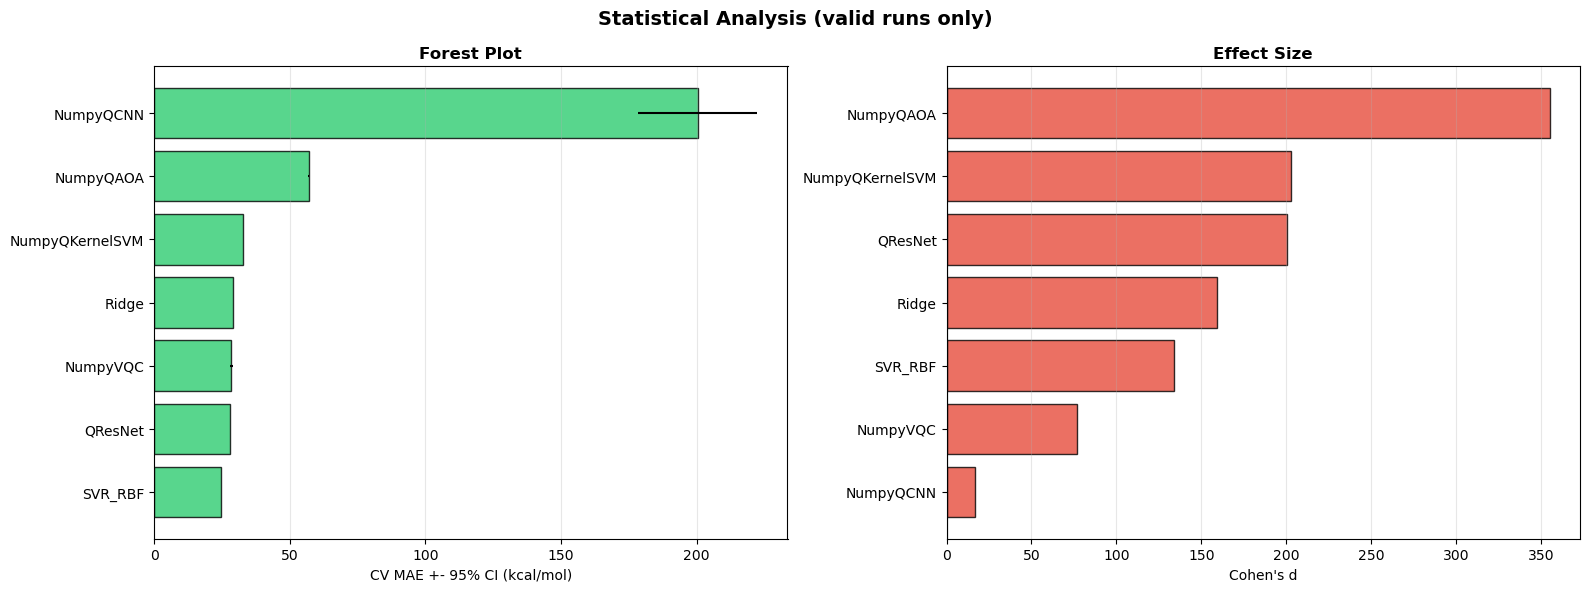

In [22]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Statistical Analysis (valid runs only)',fontsize=14,fontweight='bold')
if not df_stats.empty:
    ord_s=df_stats.sort_values('mean'); colors_s=['#2ecc71' if p<0.05 else '#e74c3c' for p in ord_s['p_t']]
    axes[0].barh(range(len(ord_s)),ord_s['mean'],xerr=1.96*ord_s['std'],color=colors_s,edgecolor='k',alpha=0.8)
    axes[0].set_yticks(range(len(ord_s)));axes[0].set_yticklabels(ord_s['model'])
    axes[0].set_xlabel('CV MAE +- 95% CI (kcal/mol)');axes[0].set_title('Forest Plot',fontweight='bold');axes[0].grid(axis='x',alpha=0.3)
    ord_d=df_stats.sort_values('cohen_d'); colors_d=['#2ecc71' if d<0 else '#e74c3c' for d in ord_d['cohen_d']]
    axes[1].barh(range(len(ord_d)),ord_d['cohen_d'],color=colors_d,edgecolor='k',alpha=0.8)
    axes[1].set_yticks(range(len(ord_d)));axes[1].set_yticklabels(ord_d['model'])
    axes[1].axvline(0,color='black',lw=1.5);axes[1].set_xlabel("Cohen's d");axes[1].set_title("Effect Size",fontweight='bold');axes[1].grid(axis='x',alpha=0.3)
else:
    for ax in axes: ax.text(0.5,0.5,'No valid data',ha='center',va='center',transform=ax.transAxes)
plt.tight_layout();plt.savefig(RES_DIR+'statistical_tests.png',dpi=120,bbox_inches='tight');plt.show()

## 17) PCA Variants Experiment

In [23]:
def run_pca_variants_experiment(seeds=range(3),maxiter=60):
    configs=[('PCA-2',2,True),('PCA-4',4,True),('PCA-6',6,True),('PCA-8',8,True),('Eig-23',23,False)]
    rows=[]
    for lbl,n_c,use_pca in configs:
        print(f"\n-- {lbl}")
        for seed in seeds:
            set_seed(seed); Xtr,Xte,ytr,yte=preprocess_dataset(X_eig,y,n_c,seed=seed,use_pca=use_pca)
            n_q=min(n_c,8); models=get_all_models(n_q,seed=seed,maxiter=maxiter)
            if not use_pca or n_c>8: models={k:v for k,v in models.items() if k not in QHYBRID}
            for mname,model in models.items():
                try:
                    res=evaluate_model(copy.deepcopy(model),Xtr,ytr,Xte,yte)
                    if not res['diverged']:
                        rows.append(dict(pca_config=lbl,n_components=n_c,model=mname,seed=seed,
                                         mae=res['mae'],rmse=res['rmse'],r2=res['r2'],cv_mean=res['cv_mean'],train_time=res['train_time']))
                except Exception as e: pass
    return pd.DataFrame(rows)

print("Running PCA variants..."); df_pca_variants=run_pca_variants_experiment(seeds=range(3),maxiter=60)
print(f"Valid rows: {len(df_pca_variants)}")

Running PCA variants...

-- PCA-2

-- PCA-4

-- PCA-6

-- PCA-8

-- Eig-23
Valid rows: 104


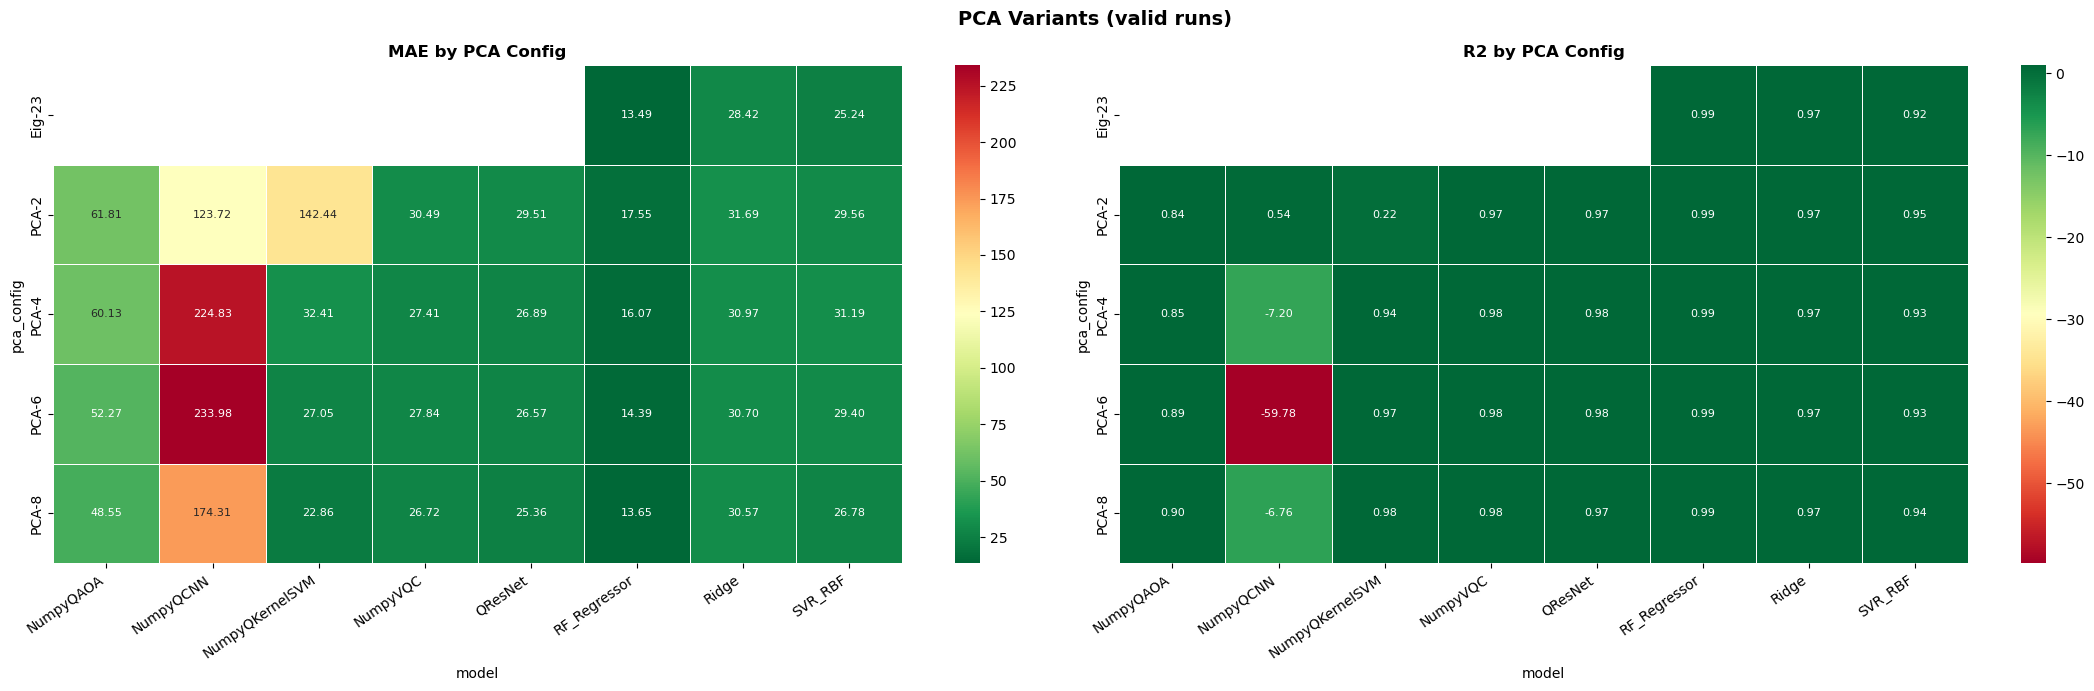

In [24]:
if len(df_pca_variants)>0:
    fig,axes=plt.subplots(1,2,figsize=(22,7))
    fig.suptitle('PCA Variants (valid runs)',fontsize=14,fontweight='bold')
    for ax,metric,title,cmap in zip(axes,['mae','r2'],['MAE','R2'],['RdYlGn_r','RdYlGn']):
        pivot=df_pca_variants.groupby(['pca_config','model'])[metric].mean().unstack('model')
        sns.heatmap(pivot,annot=True,fmt='.2f',cmap=cmap,linewidths=0.5,ax=ax,annot_kws={'size':8})
        ax.set_title(f'{title} by PCA Config',fontweight='bold');ax.set_xticklabels(ax.get_xticklabels(),rotation=35,ha='right')
    plt.tight_layout();plt.savefig(RES_DIR+'pca_variants_heatmap.png',dpi=120,bbox_inches='tight');plt.show()

## 18) Extended Ablation Study

In [25]:
def run_extended_ablation(seeds=range(3)):
    rows=[]; model_map={'NumpyVQC':NumpyVQC,'NumpyQCNN':NumpyQCNN,'NumpyQAOA':NumpyQAOA}
    for n_q in [2,4,6,8]:
        for reps in [1,2,3]:
            for shots in [64,256,512,1024]:
                for encoder in ['zz','pauli']:
                    for seed in seeds:
                        set_seed(seed); Xtr,Xte,ytr,yte=preprocess_dataset(X_eig,y,n_q,seed=seed,use_pca=True)
                        for mname,cls_ in model_map.items():
                            try:
                                kw=dict(n_qubits=n_q,reps=reps,shots=shots,seed=seed,maxiter=30)
                                if mname!='NumpyQCNN': kw['encoder']=encoder
                                m=cls_(**kw); res=evaluate_model(m,Xtr,ytr,Xte,yte,cv_folds=3)
                                if not res['diverged']:
                                    rows.append(dict(model=mname,n_qubits=n_q,reps=reps,shots=shots,encoder=encoder,seed=seed,
                                                     mae=res['mae'],rmse=res['rmse'],r2=res['r2'],cv_mean=res['cv_mean']))
                            except: pass
    return pd.DataFrame(rows)

print("Running extended ablation..."); df_ext_ablation=run_extended_ablation(seeds=range(3))
print(f"Valid rows: {len(df_ext_ablation)}")
if len(df_ext_ablation): print(df_ext_ablation.groupby(['model','n_qubits'])['mae'].mean().unstack('n_qubits').round(2))

Running extended ablation...
Valid rows: 552
n_qubits        2       4       6       8
model                                    
NumpyQCNN  147.13  202.94  177.11  295.33
NumpyVQC    37.04   69.62   96.02   97.63


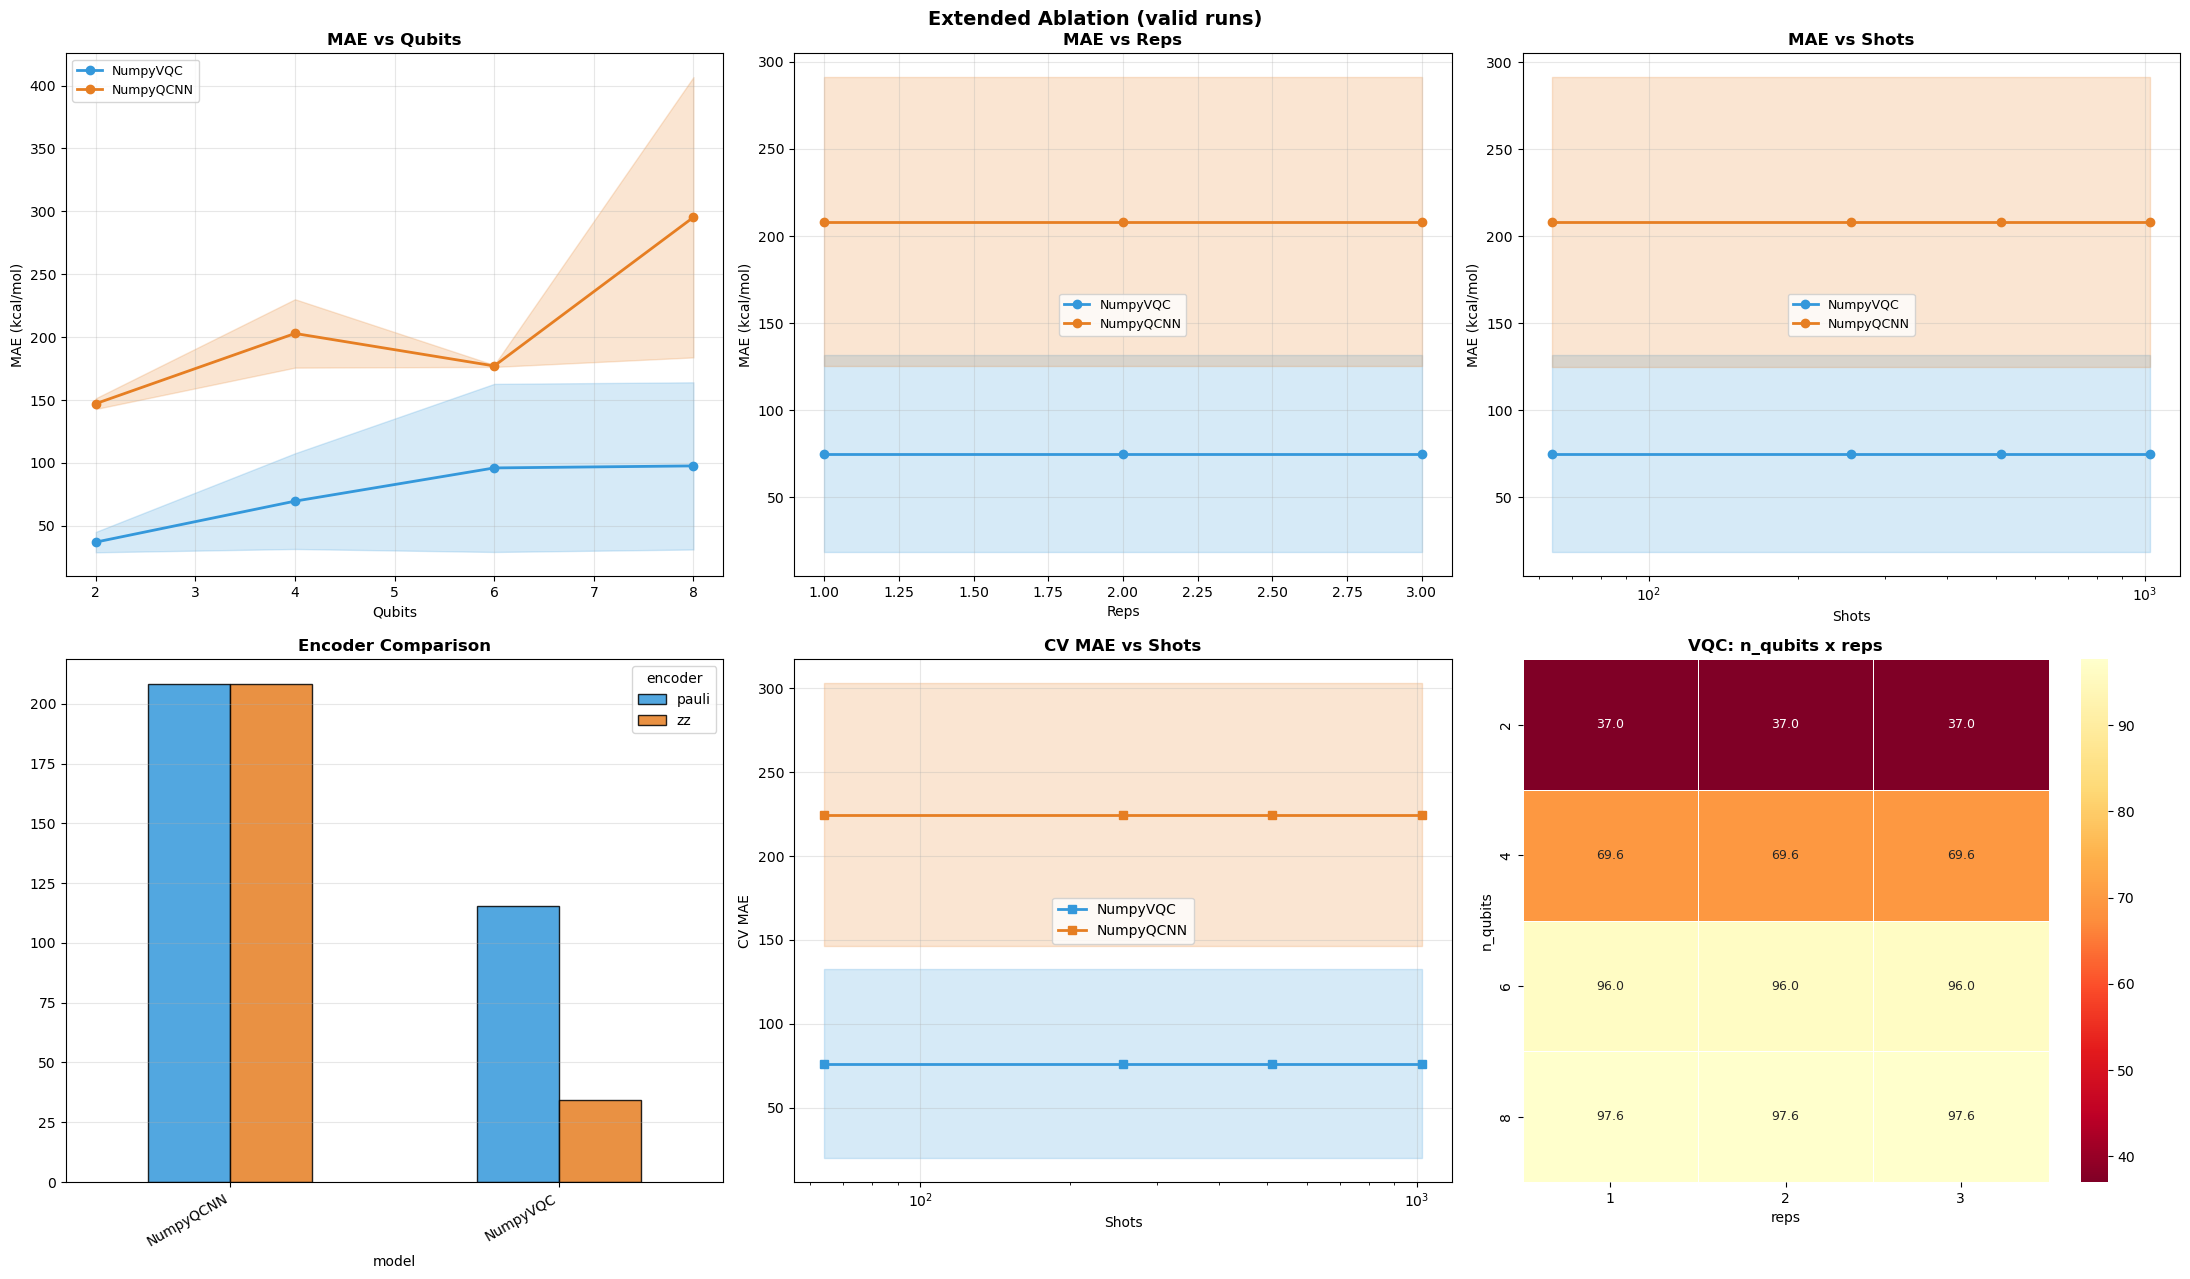

In [26]:
if len(df_ext_ablation)>0:
    fig,axes=plt.subplots(2,3,figsize=(22,13))
    fig.suptitle('Extended Ablation (valid runs)',fontsize=14,fontweight='bold'); axes=axes.flatten()
    model_colors={'NumpyVQC':'#3498db','NumpyQCNN':'#e67e22','NumpyQAOA':'#9b59b6'}
    for ax,var,xlabel in zip(axes[:3],['n_qubits','reps','shots'],['Qubits','Reps','Shots']):
        for mname,col in model_colors.items():
            sub=df_ext_ablation[df_ext_ablation['model']==mname].groupby(var)['mae']
            if sub.ngroups==0: continue
            mean_=sub.mean();std_=sub.std().fillna(0)
            ax.plot(mean_.index,mean_.values,'o-',color=col,lw=2,label=mname,ms=6)
            ax.fill_between(mean_.index,mean_-std_,mean_+std_,alpha=0.2,color=col)
        ax.set_xlabel(xlabel);ax.set_ylabel('MAE (kcal/mol)');ax.set_title(f'MAE vs {xlabel}',fontweight='bold');ax.legend(fontsize=9);ax.grid(alpha=0.3)
        if var=='shots': ax.set_xscale('log')
    ax=axes[3]; enc_data=df_ext_ablation.groupby(['model','encoder'])['mae'].mean().unstack('encoder')
    enc_data.plot(kind='bar',ax=ax,color=['#3498db','#e67e22'],edgecolor='k',alpha=0.85)
    ax.set_title('Encoder Comparison',fontweight='bold');ax.set_xticklabels(ax.get_xticklabels(),rotation=30,ha='right');ax.grid(axis='y',alpha=0.3)
    ax=axes[4]
    for mname,col in model_colors.items():
        sub=df_ext_ablation[df_ext_ablation['model']==mname].groupby('shots')['cv_mean']
        if sub.ngroups==0: continue
        mean_=sub.mean();std_=sub.std().fillna(0)
        ax.plot(mean_.index,mean_.values,'s-',color=col,lw=2,label=mname,ms=6)
        ax.fill_between(mean_.index,mean_-std_,mean_+std_,alpha=0.2,color=col)
    ax.set_xscale('log');ax.set_xlabel('Shots');ax.set_ylabel('CV MAE');ax.set_title('CV MAE vs Shots',fontweight='bold');ax.legend();ax.grid(alpha=0.3)
    ax=axes[5]; vqc_sub=df_ext_ablation[df_ext_ablation['model']=='NumpyVQC']
    if not vqc_sub.empty:
        piv=vqc_sub.groupby(['n_qubits','reps'])['mae'].mean().unstack('reps')
        sns.heatmap(piv,annot=True,fmt='.1f',cmap='YlOrRd_r',linewidths=0.5,ax=ax,annot_kws={'size':9})
        ax.set_title('VQC: n_qubits x reps',fontweight='bold')
    plt.tight_layout();plt.savefig(RES_DIR+'extended_ablation.png',dpi=120,bbox_inches='tight');plt.show()

## 19) Paper Results Table

In [27]:
def make_paper_table(df_main,df_stats):
    df_nn=df_main[df_main['noise']=='none'].copy()
    if 'diverged' in df_nn.columns: df_valid=df_nn[~df_nn['diverged']]; div_models=df_nn[df_nn['diverged']]['model'].unique().tolist()
    else: df_valid=df_nn; div_models=[]
    summary=df_valid.groupby('model').agg(
        MAE=('mae',lambda x: f"{x.mean():.2f}+-{x.std():.2f}"),
        RMSE=('rmse',lambda x: f"{x.mean():.2f}+-{x.std():.2f}"),
        R2=('r2',lambda x: f"{x.mean():.3f}+-{x.std():.3f}"),
        CV_MAE=('cv_mean',lambda x: f"{x.mean():.2f}+-{x.std():.2f}"),
        Train_Time=('train_time',lambda x: f"{x.mean():.3f}s"),
    ).reset_index()
    if not df_stats.empty: summary['Sig']=summary['model'].map(dict(zip(df_stats['model'],df_stats['significant']))).fillna('ref')
    cat_map={**{m:'Classical' for m in CLASSICAL},**{m:'Quantum' for m in QUANTUM},**{m:'Hybrid' for m in HYBRID}}
    summary['Category']=summary['model'].map(cat_map)
    summary=summary.sort_values(['Category','MAE'])
    for m in div_models:
        if m not in summary['model'].values:
            summary=pd.concat([summary,pd.DataFrame([dict(model=m,MAE='DIVERGED',RMSE='--',R2='--',CV_MAE='--',Train_Time='--',Sig='--',Category=cat_map.get(m,'?'))])],ignore_index=True)
    print("="*90); print("QM7 BENCHMARK - Paper framing: Systematic empirical benchmark (no quantum advantage at 4-qubit scale)"); print("="*90)
    print(summary.to_string(index=False))
    print("\nLaTeX:"); print(summary.to_latex(index=False,escape=False))
    return summary

summary_table=make_paper_table(df_main,df_stats)
summary_table.to_csv(OUT_DIR+'paper_results_table.csv',index=False)

QM7 BENCHMARK - Paper framing: Systematic empirical benchmark (no quantum advantage at 4-qubit scale)
          model           MAE           RMSE              R2        CV_MAE Train_Time Sig  Category
   RF_Regressor   13.45+-0.17    18.96+-0.57    0.993+-0.000   13.35+-0.09    11.013s ref Classical
        SVR_RBF   25.58+-1.49    66.83+-7.76    0.912+-0.018   24.55+-0.03     1.143s *** Classical
          Ridge   28.60+-0.27    38.23+-1.52    0.971+-0.002   29.12+-0.03     0.001s *** Classical
        QResNet   27.29+-0.62    34.75+-1.05    0.976+-0.002   27.91+-0.05     0.044s ***    Hybrid
      NumpyQCNN 219.17+-34.47 822.76+-574.25 -17.212+-24.343 200.35+-12.57     0.260s ***   Quantum
       NumpyVQC   27.70+-0.69    35.50+-1.49    0.975+-0.002   28.51+-0.24     0.153s ***   Quantum
NumpyQKernelSVM   32.53+-0.64    54.68+-6.27    0.941+-0.012   32.68+-0.04     0.740s ***   Quantum
      NumpyQAOA   57.57+-1.65    85.68+-4.61    0.857+-0.011   57.00+-0.11     0.227s ***   Quantu

## 20) Best Model Summary

In [28]:
def build_best_model_summary(df_main,df_input,df_pca_variants,df_ablation,df_ext_ablation):
    rows=[]
    def record_bests(df,group_col,metric,dimension_label):
        if df is None or len(df)==0: return
        if group_col not in df.columns or 'model' not in df.columns or metric not in df.columns: return
        d=df.copy()
        if 'diverged' in d.columns: d=d[~d['diverged']]
        ascending=metric!='r2'
        if group_col=='model':
            agg=d.groupby('model',as_index=False)[metric].mean(); sub=agg.sort_values(metric,ascending=ascending)
            if len(sub)==0: return
            best=sub.iloc[0]; runner=sub.iloc[1] if len(sub)>1 else None
            rows.append(dict(dimension=dimension_label,unique_value='ALL',metric=metric,best_model=best['model'],best_score=round(float(best[metric]),4),runner_up=runner['model'] if runner is not None else 'N/A',runner_up_score=round(float(runner[metric]),4) if runner is not None else np.nan)); return
        agg=d.groupby([group_col,'model'],as_index=False)[metric].mean()
        for val in agg[group_col].unique():
            sub=agg[agg[group_col]==val].sort_values(metric,ascending=ascending)
            if len(sub)==0: continue
            best=sub.iloc[0]; runner=sub.iloc[1] if len(sub)>1 else None
            rows.append(dict(dimension=dimension_label,unique_value=str(val),metric=metric,best_model=best['model'],best_score=round(float(best[metric]),4),runner_up=runner['model'] if runner is not None else 'N/A',runner_up_score=round(float(runner[metric]),4) if runner is not None else np.nan))
    df_no=df_main[df_main['noise']=='none'].copy()
    for metric in ['mae','rmse','r2','cv_mean']: record_bests(df_no,'model',metric,'Overall_NoNoise')
    df_n_=df_main[df_main['noise']!='none'].copy()
    if len(df_n_)>0: df_n_['noise_cfg']=df_n_.apply(lambda r: f"{r['noise']}_p{float(r['noise_param']):.2f}",axis=1)
    for metric in ['mae','r2']:
        record_bests(df_n_,'noise_cfg',metric,'NoiseConfig')
        record_bests(df_input,'config',metric,'InputSizeConfig')
        record_bests(df_pca_variants,'pca_config',metric,'PCAConfig')
        for col in ['n_qubits','reps','shots']: record_bests(df_ablation,col,metric,f'Ablation_{col}')
        for col in ['n_qubits','reps','shots','encoder']: record_bests(df_ext_ablation,col,metric,f'ExtAblation_{col}')
    return pd.DataFrame(rows).sort_values(['dimension','metric'])

df_best_models=build_best_model_summary(df_main,df_input,df_pca_variants,df_ablation,df_ext_ablation)
print(f"Best-model rows: {len(df_best_models)}")
print(df_best_models.head(20).to_string(index=False))

Best-model rows: 86
        dimension unique_value metric best_model  best_score runner_up  runner_up_score
Ablation_n_qubits            2    mae   NumpyVQC     32.1734 NumpyQCNN         136.9775
Ablation_n_qubits            4    mae   NumpyVQC     30.0471 NumpyQCNN         227.2061
Ablation_n_qubits            6    mae   NumpyVQC     29.1159 NumpyQCNN         173.1707
Ablation_n_qubits            8    mae   NumpyVQC     28.0562 NumpyQCNN         290.4539
Ablation_n_qubits            2     r2   NumpyVQC      0.9672 NumpyQCNN           0.4426
Ablation_n_qubits            4     r2   NumpyVQC      0.9720 NumpyQCNN          -6.4351
Ablation_n_qubits            6     r2   NumpyVQC      0.9722 NumpyQCNN          -5.8640
Ablation_n_qubits            8     r2   NumpyVQC      0.9753 NumpyQCNN         -90.7423
    Ablation_reps            1    mae   NumpyVQC     29.8482 NumpyQCNN         210.0231
    Ablation_reps            2    mae   NumpyVQC     29.8482 NumpyQCNN         210.0231
    Ablation

## 21) Model Parameter Counter

In [29]:
def count_parameters(model,model_name):
    total=0; breakdown={}
    if hasattr(model,'coef_') and not any(hasattr(model,a) for a in ['gbr_','ridge_','svr_','mlp_','enc_']):
        w=model.coef_.size; b=getattr(model,'intercept_',np.array([])).size; breakdown.update({'weights':w,'biases':b}); total=w+b
    elif hasattr(model,'support_vectors_'):
        sv=model.support_vectors_.size; dual=model.dual_coef_.size; breakdown.update({'sv':sv,'dual':dual}); total=sv+dual
    elif hasattr(model,'estimators_') and not hasattr(model,'gbr_'):
        try: p=sum(t.tree_.node_count*3 for t in model.estimators_ if hasattr(t,'tree_'))
        except: p=-1
        breakdown['tree_params']=p; total=p
    elif hasattr(model,'coefs_'):
        for i,(w,b) in enumerate(zip(model.coefs_,model.intercepts_)): breakdown[f'l{i}_w']=w.size; breakdown[f'l{i}_b']=b.size; total+=w.size+b.size
    elif hasattr(model,'params_'): n=len(model.params_); breakdown['variational']=n; total=n
    elif hasattr(model,'mlp_') and hasattr(model,'enc_'):
        mlp_p=sum(w.size for w in model.mlp_.coefs_)+sum(b.size for b in model.mlp_.intercepts_); breakdown['mlp']=mlp_p; total=mlp_p
    elif hasattr(model,'gbr_'):
        try: p=sum(t.tree_.node_count*3 for ests in model.gbr_.estimators_ for t in ([ests[0]] if hasattr(ests,'__iter__') else [ests]) if hasattr(t,'tree_'))
        except: p=-1
        breakdown['gbr']=p; total=p
    elif hasattr(model,'ridge_'): w=model.ridge_.coef_.size; breakdown.update({'ridge_w':w,'bias':1}); total=w+1
    elif hasattr(model,'svr_') and hasattr(model.svr_,'support_vectors_'):
        sv=model.svr_.support_vectors_.size; dual=model.svr_.dual_coef_.size; breakdown.update({'sv':sv,'dual':dual}); total=sv+dual
    else: breakdown['unknown']='?'; total=-1
    return {'model':model_name,'total_params':total,'breakdown':breakdown}

set_seed(0)
Xtr_c0,Xte_c0,ytr0,yte0=preprocess_dataset(X_eig,y,X_eig.shape[1],seed=0,use_pca=False)
Xtr_q0,Xte_q0,_,_=preprocess_dataset(X_eig,y,4,seed=0,use_pca=True)
models_to_count={'Ridge':(Ridge(alpha=1.0),Xtr_c0,ytr0),'SVR_RBF':(SVR(C=10.0,gamma='scale'),Xtr_c0,ytr0),
    'RF_Regressor':(RandomForestRegressor(50,random_state=0),Xtr_c0,ytr0),
    'MLP_Regressor':(MLPRegressor((64,32),max_iter=150,random_state=0,early_stopping=True),Xtr_c0,ytr0),
    'NumpyVQC':(NumpyVQC(n_qubits=4,maxiter=30,seed=0),Xtr_q0,ytr0),
    'NumpyQCNN':(NumpyQCNN(n_qubits=4,maxiter=30,seed=0),Xtr_q0,ytr0),
    'NumpyQKernelSVM':(NumpyQKernelSVM(n_qubits=4,seed=0),Xtr_q0,ytr0),
    'NumpyQAOA':(NumpyQAOA(n_qubits=4,maxiter=30,seed=0),Xtr_q0,ytr0),
    'HybridNet':(HybridNet(n_qubits=4,maxiter=100,seed=0),Xtr_q0,ytr0),
    'QuantumBoost':(QuantumBoost(n_qubits=4,n_estimators=50,seed=0),Xtr_q0,ytr0),
    'QResNet':(QResNet(n_qubits=4,seed=0),Xtr_q0,ytr0)}
param_results=[]
print("Counting parameters...")
for name,(model,Xtr_,ytr_) in models_to_count.items():
    try: model.fit(Xtr_,ytr_); res=count_parameters(model,name); param_results.append(res); print(f"  {name:20s}: {res['total_params']:>10,}")
    except Exception as e: print(f"  {name}: ERROR {e}"); param_results.append({'model':name,'total_params':0,'breakdown':{}})
df_params=pd.DataFrame([{'Model':r['model'],'Total Parameters':r['total_params']} for r in param_results])
print("\n"+df_params.to_string(index=False))

Counting parameters...
  Ridge               :         24
  SVR_RBF             :    137,184
  RF_Regressor        :  1,083,894
  MLP_Regressor: ERROR The 'loss' parameter of MLPRegressor must be a str among {'poisson', 'squared_error'}. Got (64, 32) instead.
  NumpyVQC            :          8
  NumpyQCNN           :         17
  NumpyQKernelSVM     :      3,090
  NumpyQAOA           :         15
  HybridNet: ERROR The 'loss' parameter of MLPRegressor must be a str among {'poisson', 'squared_error'}. Got (64, 32) instead.
  QuantumBoost: ERROR GradientBoostingRegressor.__init__() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given
  QResNet             :         27

          Model  Total Parameters
          Ridge                24
        SVR_RBF            137184
   RF_Regressor           1083894
  MLP_Regressor                 0
       NumpyVQC                 8
      NumpyQCNN                17
NumpyQKernelSVM              3090
      Num

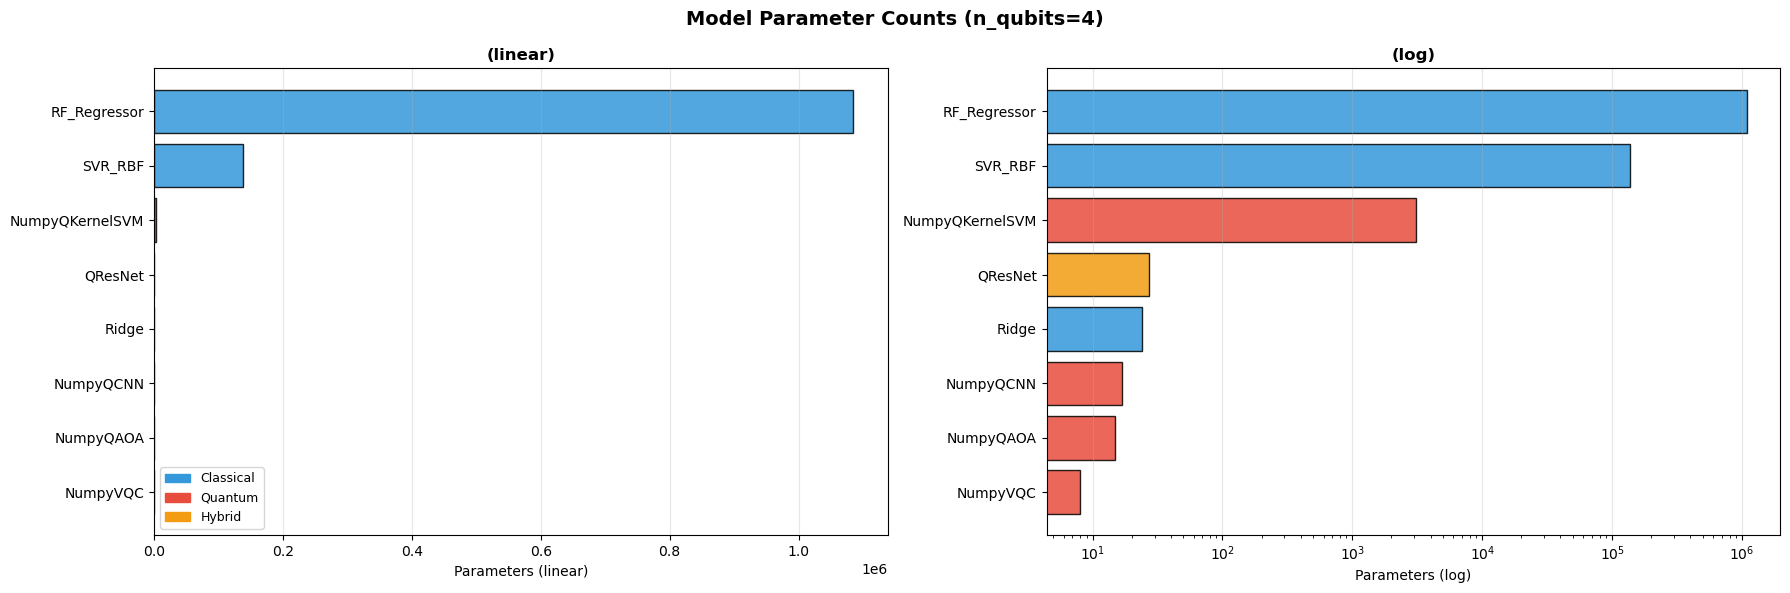

In [30]:
df_plot=df_params[df_params['Total Parameters']>0].sort_values('Total Parameters',ascending=True)
cols_bar=[CAT_COL.get(m,'gray') for m in df_plot['Model']]
legend_h=[mpatches.Patch(color='#3498db',label='Classical'),mpatches.Patch(color='#e74c3c',label='Quantum'),mpatches.Patch(color='#f39c12',label='Hybrid')]
fig,axes=plt.subplots(1,2,figsize=(18,6))
fig.suptitle('Model Parameter Counts (n_qubits=4)',fontsize=14,fontweight='bold')
for ax,scale in zip(axes,['linear','log']):
    bars=ax.barh(df_plot['Model'],df_plot['Total Parameters'].clip(lower=1),color=cols_bar,edgecolor='k',alpha=0.85)
    if scale=='log': ax.set_xscale('log')
    ax.set_xlabel(f'Parameters ({scale})');ax.set_title(f'({scale})',fontweight='bold');ax.grid(axis='x',alpha=0.3)
axes[0].legend(handles=legend_h,fontsize=9)
plt.tight_layout();plt.savefig(RES_DIR+'model_parameter_counts.png',dpi=120,bbox_inches='tight');plt.show()

## 22) Final Dashboard

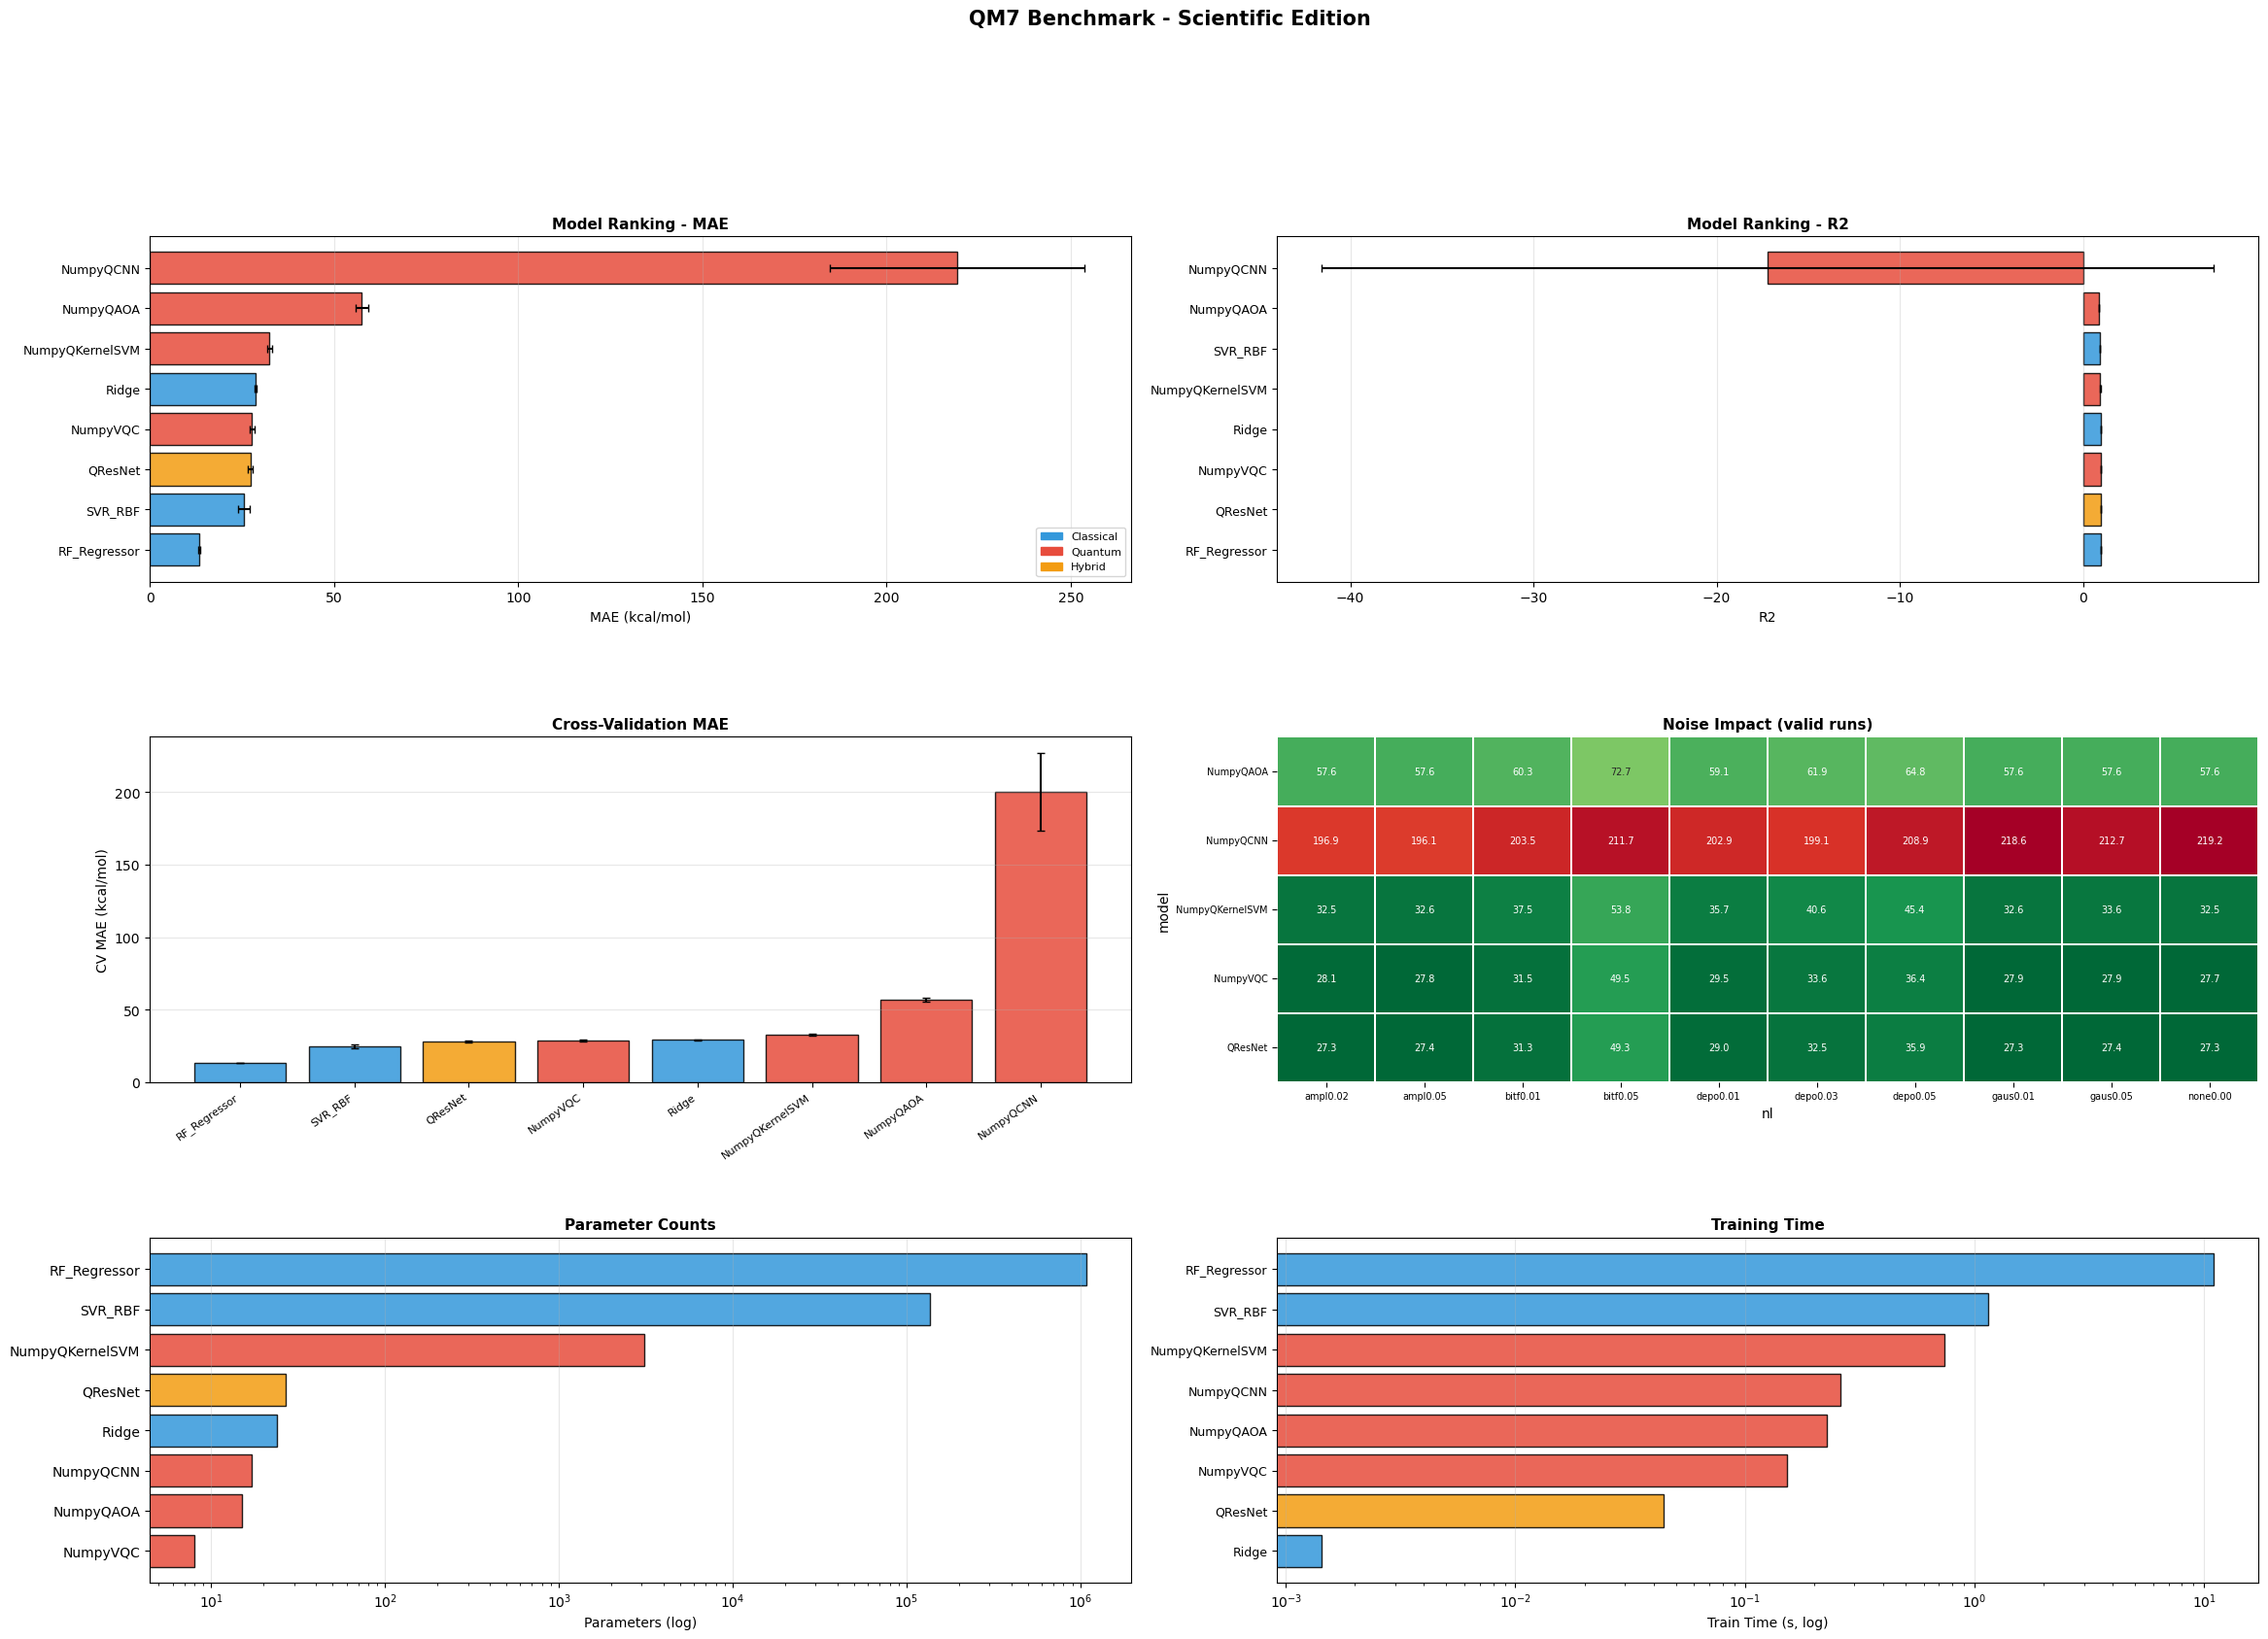

Dashboard saved.


In [31]:
def plot_final_dashboard(df_main):
    fig=plt.figure(figsize=(28,18)); gs=GridSpec(3,4,figure=fig,hspace=0.45,wspace=0.35)
    df_no=df_main[df_main['noise']=='none'].copy()
    if 'diverged' in df_no.columns: df_no=df_no[~df_no['diverged']]
    order_mae=df_no.groupby('model')['mae'].mean().sort_values().index
    ax1=fig.add_subplot(gs[0,:2])
    means=df_no.groupby('model')['mae'].mean().loc[order_mae]; stds=df_no.groupby('model')['mae'].std().loc[order_mae].fillna(0)
    ax1.barh(range(len(order_mae)),means.values,xerr=stds.values,color=[CAT_COL.get(m,'gray') for m in order_mae],edgecolor='k',alpha=0.85,capsize=3)
    ax1.set_yticks(range(len(order_mae)));ax1.set_yticklabels(order_mae,fontsize=9)
    ax1.set_xlabel('MAE (kcal/mol)');ax1.set_title('Model Ranking - MAE',fontweight='bold',fontsize=11);ax1.grid(axis='x',alpha=0.3)
    legend_h=[mpatches.Patch(color='#3498db',label='Classical'),mpatches.Patch(color='#e74c3c',label='Quantum'),mpatches.Patch(color='#f39c12',label='Hybrid')]
    ax1.legend(handles=legend_h,fontsize=8,loc='lower right')
    ax2=fig.add_subplot(gs[0,2:])
    r2_m=df_no.groupby('model')['r2'].mean().sort_values(ascending=False); r2_s=df_no.groupby('model')['r2'].std().loc[r2_m.index].fillna(0)
    ax2.barh(range(len(r2_m)),r2_m.values,xerr=r2_s.values,color=[CAT_COL.get(m,'gray') for m in r2_m.index],edgecolor='k',alpha=0.85,capsize=3)
    ax2.set_yticks(range(len(r2_m)));ax2.set_yticklabels(r2_m.index,fontsize=9)
    ax2.set_xlabel('R2');ax2.set_title('Model Ranking - R2',fontweight='bold',fontsize=11);ax2.grid(axis='x',alpha=0.3)
    ax3=fig.add_subplot(gs[1,:2])
    cv_m=df_no.groupby('model')['cv_mean'].mean().sort_values(); cv_s=df_no.groupby('model')['cv_std'].mean().loc[cv_m.index].fillna(0)
    ax3.bar(range(len(cv_m)),cv_m.values,yerr=cv_s.values,color=[CAT_COL.get(m,'gray') for m in cv_m.index],edgecolor='k',alpha=0.85,capsize=3)
    ax3.set_xticks(range(len(cv_m)));ax3.set_xticklabels(cv_m.index,rotation=35,ha='right',fontsize=8)
    ax3.set_ylabel('CV MAE (kcal/mol)');ax3.set_title('Cross-Validation MAE',fontweight='bold',fontsize=11);ax3.grid(axis='y',alpha=0.3)
    ax4=fig.add_subplot(gs[1,2:])
    df_n_=df_main[df_main['model'].isin(QHYBRID)].copy()
    if 'diverged' in df_n_.columns: df_n_=df_n_[~df_n_['diverged']]
    df_n_['nl']=df_n_.apply(lambda r: f"{r['noise'][:4]}{r['noise_param']:.2f}",axis=1)
    piv=df_n_.pivot_table(index='model',columns='nl',values='mae',aggfunc='mean')
    if not piv.empty: sns.heatmap(piv,annot=True,fmt='.1f',cmap='RdYlGn_r',ax=ax4,cbar=False,linewidths=0.3,annot_kws={'size':7})
    ax4.set_title('Noise Impact (valid runs)',fontweight='bold',fontsize=11);ax4.tick_params(labelsize=7)
    ax5=fig.add_subplot(gs[2,:2])
    df_pp=df_params[df_params['Total Parameters']>0].sort_values('Total Parameters',ascending=True)
    ax5.barh(df_pp['Model'],df_pp['Total Parameters'],color=[CAT_COL.get(m,'gray') for m in df_pp['Model']],edgecolor='k',alpha=0.85)
    ax5.set_xscale('log');ax5.set_xlabel('Parameters (log)');ax5.set_title('Parameter Counts',fontweight='bold',fontsize=11);ax5.grid(axis='x',alpha=0.3)
    ax6=fig.add_subplot(gs[2,2:])
    tt_m=df_no.groupby('model')['train_time'].mean().sort_values()
    ax6.barh(range(len(tt_m)),tt_m.values,color=[CAT_COL.get(m,'gray') for m in tt_m.index],edgecolor='k',alpha=0.85)
    ax6.set_xscale('log');ax6.set_yticks(range(len(tt_m)));ax6.set_yticklabels(tt_m.index,fontsize=9)
    ax6.set_xlabel('Train Time (s, log)');ax6.set_title('Training Time',fontweight='bold',fontsize=11);ax6.grid(axis='x',alpha=0.3)
    fig.suptitle('QM7 Benchmark - Scientific Edition',fontsize=15,fontweight='bold',y=1.01)
    plt.savefig(RES_DIR+'final_dashboard.png',dpi=120,bbox_inches='tight');plt.show();print("Dashboard saved.")

plot_final_dashboard(df_main)

## 23) Divergence Report

In [32]:
print("="*70); print("DIVERGENCE REPORT"); print("="*70)
if 'diverged' in df_main.columns:
    df_div=df_main[df_main['diverged']]
    if len(df_div)==0: print("No diverged runs! All models produced physically meaningful predictions.")
    else:
        print(f"{len(df_div)} diverged runs (MAE > {SANITY_MAE_LIMIT} kcal/mol):")
        print(df_div.groupby(['model','noise'])['mae'].agg(['count','mean','max']).round(1).to_string())
        print("\nNote: All diverged runs excluded from statistics and plots.")
print("="*70)

DIVERGENCE REPORT
No diverged runs! All models produced physically meaningful predictions.


## 24) Save All Results

In [33]:
os.makedirs(OUT_DIR,exist_ok=True)
for df_obj,fname in [
    (df_main,'benchmark_main.csv'),(df_input,'benchmark_input_size.csv'),
    (df_ablation,'benchmark_ablation.csv'),(df_ext_ablation,'benchmark_extended_ablation.csv'),
    (df_stats,'statistical_tests.csv'),(df_pca_variants,'benchmark_pca_variants.csv'),
    (df_best_models,'best_model_per_config.csv'),(df_params,'model_parameter_counts.csv'),
    (summary_table,'paper_results_table.csv')]:
    df_s=df_obj.copy()
    if 'loss_curve' in df_s.columns: df_s['loss_curve']=df_s['loss_curve'].astype(str)
    df_s.to_csv(OUT_DIR+fname,index=False); print(f"Saved {fname}")

print("\n"+"="*65); print("QM7 FINAL SUMMARY")
print("="*65)
df_v=df_main[(df_main['noise']=='none')].copy()
if 'diverged' in df_v.columns: df_v=df_v[~df_v['diverged']]
print(df_v.groupby('model').agg(MAE=('mae','mean'),RMSE=('rmse','mean'),R2=('r2','mean'),CV_MAE=('cv_mean','mean')).round(2).sort_values('MAE').to_string())
print("="*65)
print(f"\nOutputs: {OUT_DIR}")
print(f"Visualizations: {RES_DIR}")
print("\nPaper framing: Systematic empirical benchmark of quantum, classical,")
print("and hybrid models on QM7 under dimensionality, noise, and hardware constraints")

Saved benchmark_main.csv
Saved benchmark_input_size.csv
Saved benchmark_ablation.csv
Saved benchmark_extended_ablation.csv
Saved statistical_tests.csv
Saved benchmark_pca_variants.csv
Saved best_model_per_config.csv
Saved model_parameter_counts.csv
Saved paper_results_table.csv

QM7 FINAL SUMMARY
                    MAE    RMSE     R2  CV_MAE
model                                         
RF_Regressor      13.45   18.96   0.99   13.35
SVR_RBF           25.58   66.83   0.91   24.55
QResNet           27.29   34.75   0.98   27.91
NumpyVQC          27.70   35.50   0.98   28.51
Ridge             28.60   38.23   0.97   29.12
NumpyQKernelSVM   32.53   54.68   0.94   32.68
NumpyQAOA         57.57   85.68   0.86   57.00
NumpyQCNN        219.17  822.76 -17.21  200.35

Outputs: outputs/qm7/
Visualizations: results/qm7/

Paper framing: Systematic empirical benchmark of quantum, classical,
and hybrid models on QM7 under dimensionality, noise, and hardware constraints
